# Imports & SetUp

In [1]:
import os
import copy
import json
import math
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from PIL import Image
from pathlib import Path
from typing import Tuple
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import datasets, models, transforms, utils
from torch.utils.data import DataLoader, Dataset, random_split, Subset

In [4]:
import pennylane as qml
import pennylane.qnn as qnn

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [6]:
from paths_setup import TRAIN_DIR, TEST_DIR, BACKUP_DIR

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")
if not TEST_DIR.exists():
    raise FileNotFoundError(f"TEST_DIR not found: {TEST_DIR}")
if not BACKUP_DIR.exists():
    raise FileNotFoundError(f"BACKUP_DIR not found: {BACKUP_DIR}")

In [7]:
VIEW_CLASS = ["02", "06", "08", "12", "13", "14", "15", "16", "18", "21", "22", "23", "27", "30"]

missing_train = [c for c in VIEW_CLASS if not (TRAIN_DIR / c).exists()]
missing_test  = [c for c in VIEW_CLASS if not (TEST_DIR  / c).exists()]

if missing_train:
    raise FileNotFoundError(f"Missing train class folders: {missing_train}")
if missing_test:
    raise FileNotFoundError(f"Missing test class folders: {missing_test}")

In [8]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
NUM_WORKERS = 8

# Data Exploration

## General Information

In [10]:
def show_first_10_images(folder_dir: Path, view_name: str) -> None:
    
    view_dir = Path(folder_dir) / view_name
    png_files = sorted(view_dir.glob("*.png"))[:10]

    if not view_dir.exists():
        raise FileNotFoundError(f"Folder does not exist: {view_dir}")

    if len(png_files) == 0:
        raise FileNotFoundError(f"No PNG files found in: {view_dir}")

    n = len(png_files)
    rows, cols = 2, 5

    plt.figure(figsize=(cols * 3.2, rows * 3.2))

    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.axis("off")

        if i < n:
            img = Image.open(png_files[i])
            plt.imshow(img)
        else:
            plt.text(0.5, 0.5, "EMPTY", ha="center", va="center")

    plt.tight_layout()
    plt.show()

In [11]:
def count_pngs(folder: Path) -> int:
    
    if not folder.exists() or not folder.is_dir():
        return 0
    return sum(1 for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".png")

In [12]:
def print_view_image_counts(view_name: str) -> Tuple[int, int]:

    view_name = str(view_name).strip()
    
    train_view_dir = TRAIN_DIR / view_name
    test_view_dir  = TEST_DIR / view_name

    train_count = count_pngs(train_view_dir)
    test_count  = count_pngs(test_view_dir)

    return train_count, test_count

In [13]:
total_train = 0
total_test  = 0
counts_matrix = []

print(f"--- Data Summary ---")

for vc in VIEW_CLASS:
    temp_train, temp_test = print_view_image_counts(vc)

    counts_matrix.append([temp_train, temp_test])
    
    total_train += temp_train
    total_test  += temp_test
    
    print(f"View {vc}: {temp_train + temp_test} images ({temp_train} train images; {temp_test} test images)")
    
print(f"Total: {total_train + total_test} images ({total_train} train images; {total_test} test images)")

--- Data Summary ---
View 02: 19566 images (15317 train images; 4249 test images)
View 06: 10401 images (10000 train images; 401 test images)
View 08: 13020 images (10272 train images; 2748 test images)
View 12: 22663 images (18030 train images; 4633 test images)
View 13: 17814 images (14385 train images; 3429 test images)
View 14: 11139 images (10000 train images; 1139 test images)
View 15: 31473 images (25052 train images; 6421 test images)
View 16: 12061 images (10000 train images; 2061 test images)
View 18: 11058 images (10000 train images; 1058 test images)
View 21: 14059 images (11160 train images; 2899 test images)
View 22: 10895 images (10000 train images; 895 test images)
View 23: 13723 images (10930 train images; 2793 test images)
View 27: 11670 images (10000 train images; 1670 test images)
View 30: 10803 images (10000 train images; 803 test images)
Total: 210345 images (175146 train images; 35199 test images)


In [14]:
def plot_train_test_counts_stacked(view_classes: list[str], counts_matrix: list[list[int]]) -> None:
    
    if len(view_classes) != len(counts_matrix):
        raise ValueError(f"Length mismatch: view_classes - {len(view_classes)} entries, counts_matrix - {len(counts_matrix)} rows")

    train_counts = [row[0] for row in counts_matrix]
    test_counts  = [row[1] for row in counts_matrix]

    x = list(range(len(view_classes)))

    plt.figure(figsize=(max(10, len(view_classes) * 0.9), 5))

    plt.bar(x, train_counts, width=0.80, color="C0", label="Train")
    plt.bar(x, test_counts,  width=0.80, color="C1", label="Test", bottom=train_counts)

    plt.xticks(x, view_classes)
    plt.xlabel("View")
    plt.ylabel("Number of Images (Train + Test)")
    plt.title("Images per View")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
def plot_train_test_counts_overlaid(view_classes: list[str], counts_matrix: list[list[int]]) -> None:
    
    if len(view_classes) != len(counts_matrix):
        raise ValueError(f"Length mismatch: view_classes - {len(view_classes)} entries, counts_matrix - {len(counts_matrix)} rows")

    train_counts = [row[0] for row in counts_matrix]
    test_counts  = [row[1] for row in counts_matrix]

    x = list(range(len(view_classes)))
    
    plt.figure(figsize=(max(10, len(view_classes) * 0.9), 5))

    plt.bar(x, train_counts, width=0.80, color="C0", alpha=0.5, label="Train", zorder=1)
    plt.bar(x, test_counts,  width=0.80, color="C1", alpha=0.5, label="Test",  zorder=2)

    plt.xticks(x, view_classes)
    plt.xlabel("View")
    plt.ylabel("Number of Images (Train and Test - Overlaid)")
    plt.title("Images per View")
    plt.legend()
    plt.tight_layout()
    plt.show()

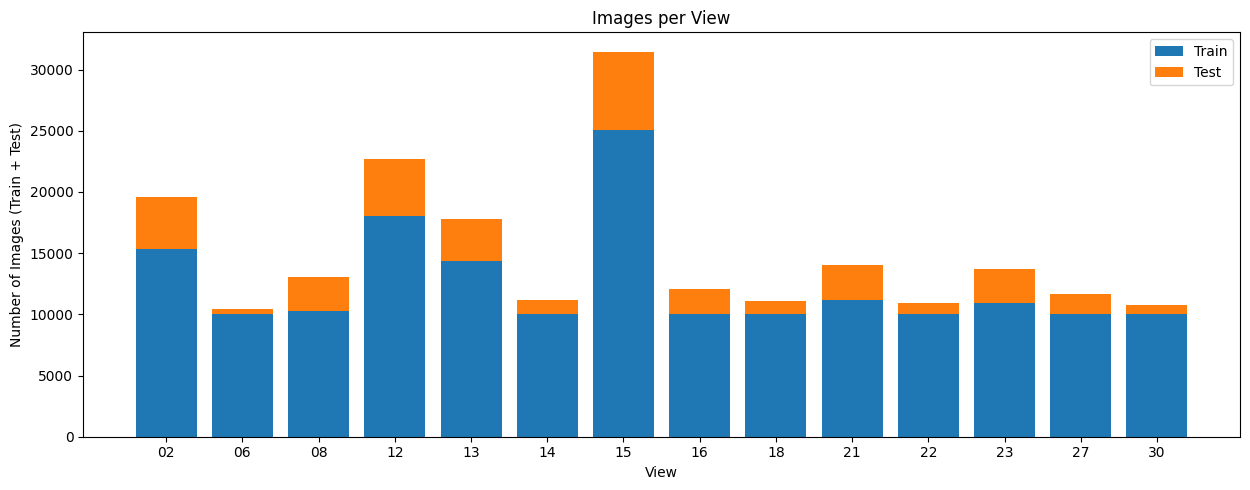

In [16]:
plot_train_test_counts_stacked(VIEW_CLASS, counts_matrix)

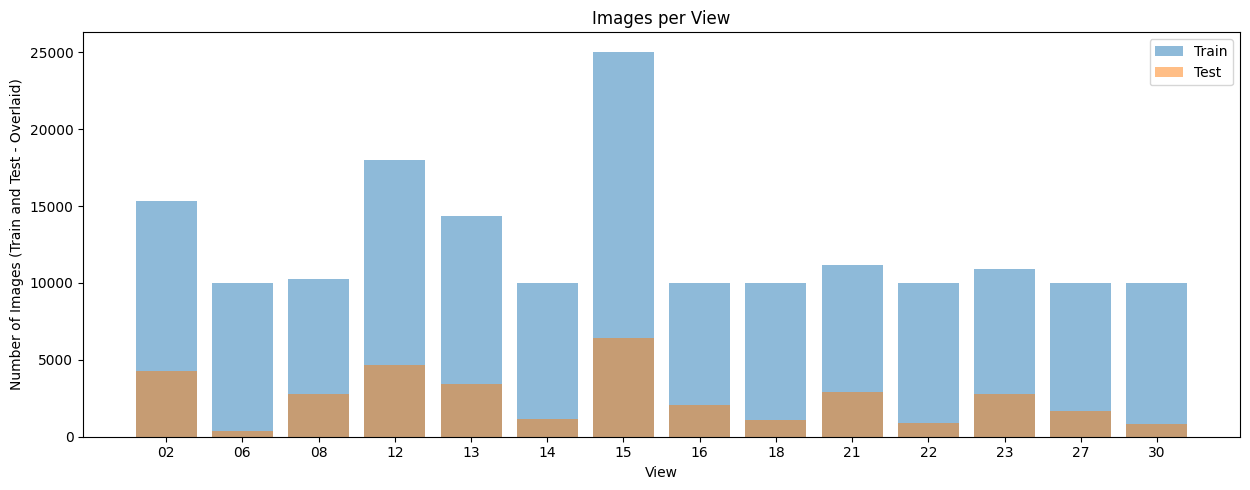

In [17]:
plot_train_test_counts_overlaid(VIEW_CLASS, counts_matrix)

## Label Mapping

In [18]:
class_to_idx = {name: i for i, name in enumerate(VIEW_CLASS)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

print("Label mapping:")
for k in sorted(class_to_idx.keys()):
    print(f"   {k} -> {class_to_idx[k]}")

Label mapping:
   02 -> 0
   06 -> 1
   08 -> 2
   12 -> 3
   13 -> 4
   14 -> 5
   15 -> 6
   16 -> 7
   18 -> 8
   21 -> 9
   22 -> 10
   23 -> 11
   27 -> 12
   30 -> 13


## Check Image Size Consistency

In [19]:
EXCLUDED_FILES = []
run_verify_image_dimensions = 0

In [20]:
def verify_image_dimensions(folder_dir: Path, target_size: Tuple[int, int]) -> None:
    print(f"Checking image dimensions in {folder_dir}:")
    total_mismatch = 0 
    
    for class_name in VIEW_CLASS:
        mismatch_count = 0
        
        print(f"\n   View {class_name}:")
        class_path = folder_dir / class_name
        if not class_path.exists():
            continue
            
        for img_path in class_path.glob("*.png"):
            with Image.open(img_path) as img:
                if img.size != target_size:
                    mismatch_count += 1
                    total_mismatch += 1
                    EXCLUDED_FILES.append(img_path.name)
                    print(f"      Mismatch found: {img_path.name} is {img.size}")

        if mismatch_count == 0:
            print("      No mismatches found")

    if total_mismatch == 0:
        print(f"\nSuccess: All images are confirmed to be {target_size}")
    else:
        print(f"\nWARNING: Found {total_mismatch} images with inconsistent sizes")

In [21]:
verify_image_dimensions(TRAIN_DIR, IMG_SIZE)
verify_image_dimensions(TEST_DIR,  IMG_SIZE)
run_verify_image_dimensions = 1

Checking image dimensions in /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/Dataset/View Classification/train:

   View 02:
      Mismatch found: __Amy__DicomIMG_ID_69214103__20200810140438__1.png is (432, 288)
      Mismatch found: __DCM__DicomIMG_ID_60302307__nk095938.000000__1.png is (432, 288)

   View 06:
      No mismatches found

   View 08:
      No mismatches found

   View 12:
      No mismatches found

   View 13:
      No mismatches found

   View 14:
      No mismatches found

   View 15:
      No mismatches found

   View 16:
      No mismatches found

   View 18:
      No mismatches found

   View 21:
      No mismatches found

   View 22:
      No mismatches found

   View 23:
      No mismatches found

   View 27:
      No mismatches found

   View 30:
      No mismatches found

Checking image dimensions in /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/Dataset/View Classification/test:

   View 02:
      No mismatches found

   View 06:
      No mismatches found

   Vie

In [22]:
if run_verify_image_dimensions == 0:
    EXCLUDED_FILES = ['__Amy__DicomIMG_ID_69214103__20200810140438__1.png', '__DCM__DicomIMG_ID_60302307__nk095938.000000__1.png']
print(f"Files to exclude: {EXCLUDED_FILES}")

Files to exclude: ['__Amy__DicomIMG_ID_69214103__20200810140438__1.png', '__DCM__DicomIMG_ID_60302307__nk095938.000000__1.png']


## View 02

In [ ]:
show_first_10_images(TRAIN_DIR, "02")
show_first_10_images(TEST_DIR,  "02")

## View 06

In [ ]:
show_first_10_images(TRAIN_DIR, "06")
show_first_10_images(TEST_DIR,  "06")

## View 08

In [ ]:
show_first_10_images(TRAIN_DIR, "08")
show_first_10_images(TEST_DIR,  "08")

## View 12

In [ ]:
show_first_10_images(TRAIN_DIR, "12")
show_first_10_images(TEST_DIR,  "12")

## View 13

In [ ]:
show_first_10_images(TRAIN_DIR, "13")
show_first_10_images(TEST_DIR,  "13")

## View 14

In [ ]:
show_first_10_images(TRAIN_DIR, "14")
show_first_10_images(TEST_DIR,  "14")

## View 15

In [ ]:
show_first_10_images(TRAIN_DIR, "15")
show_first_10_images(TEST_DIR,  "15")

## View 16

In [ ]:
show_first_10_images(TRAIN_DIR, "16")
show_first_10_images(TEST_DIR,  "16")

## View 18

In [ ]:
show_first_10_images(TRAIN_DIR, "18")
show_first_10_images(TEST_DIR,  "18")

## View 21

In [ ]:
show_first_10_images(TRAIN_DIR, "21")
show_first_10_images(TEST_DIR,  "21")

## View 22

In [ ]:
show_first_10_images(TRAIN_DIR, "22")
show_first_10_images(TEST_DIR,  "22")

## View 23

In [ ]:
show_first_10_images(TRAIN_DIR, "23")
show_first_10_images(TEST_DIR,  "23")

## View 27

In [ ]:
show_first_10_images(TRAIN_DIR, "27")
show_first_10_images(TEST_DIR,  "27")

## View 30

In [ ]:
show_first_10_images(TRAIN_DIR, "30")
show_first_10_images(TEST_DIR,  "30")

# Data Preprocessing

## Data Transforms

In [23]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
    
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
}

## Load & Split Data

In [24]:
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        
        if self.transform:
            x = self.transform(x)
            
        return x, y
        
    def __len__(self):
        return len(self.subset)

In [25]:
def is_valid_image(path):
    if os.path.basename(path) in EXCLUDED_FILES:
        return False 
    return path.lower().endswith('.png')

In [26]:
base_dataset = datasets.ImageFolder(root=TRAIN_DIR, is_valid_file=is_valid_image) 

train_size = int((1 - VAL_SPLIT) * len(base_dataset))
val_size = len(base_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(base_dataset, [train_size, val_size], generator=generator)

train_data = TransformedSubset(train_subset, transform=data_transforms['train'])
val_data   = TransformedSubset(val_subset,   transform=data_transforms['val'])

test_data = datasets.ImageFolder(root=TEST_DIR, is_valid_file=is_valid_image, transform=data_transforms['val'])

In [27]:
def get_counts(subset):
    targets = [subset.dataset.targets[i] for i in subset.indices]
    return np.bincount(targets, minlength=len(base_dataset.classes))

train_counts = get_counts(train_subset)
val_counts = get_counts(val_subset)
test_counts = np.bincount(test_data.targets, minlength=len(base_dataset.classes))

print(f"Dataset split (Total = {len(base_dataset) + len(test_data)}):")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Train = {train_counts[i]}, Val = {val_counts[i]}, Test = {test_counts[i]}")

print("Training set size: ", len(train_data))
print("Validation set size: ", len(val_data))
print("Test set size: ", len(test_data))

Dataset split (Total = 210343):
   View 02: Train = 12276, Val = 3039, Test = 4249
   View 06: Train = 7911, Val = 2089, Test = 401
   View 08: Train = 8211, Val = 2061, Test = 2748
   View 12: Train = 14457, Val = 3573, Test = 4633
   View 13: Train = 11455, Val = 2930, Test = 3429
   View 14: Train = 8009, Val = 1991, Test = 1139
   View 15: Train = 20015, Val = 5037, Test = 6421
   View 16: Train = 7995, Val = 2005, Test = 2061
   View 18: Train = 8030, Val = 1970, Test = 1058
   View 21: Train = 8917, Val = 2243, Test = 2899
   View 22: Train = 8037, Val = 1963, Test = 895
   View 23: Train = 8771, Val = 2159, Test = 2793
   View 27: Train = 7971, Val = 2029, Test = 1670
   View 30: Train = 8060, Val = 1940, Test = 803
Training set size:  140115
Validation set size:  35029
Test set size:  35199


## Class Weights

In [28]:
base_targets = train_data.subset.dataset.targets
train_indices = train_data.subset.indices
train_targets = [base_targets[i] for i in train_indices]

class_counts = np.bincount(train_targets)
total_samples = len(train_targets)
num_classes = len(class_counts)

class_weights = total_samples / (num_classes * class_counts)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

In [29]:
print("Class weights:")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Count = {class_counts[i]}, Weight = {class_weights[i]:.4f}")

Class weights:
   View 02: Count = 12276, Weight = 0.8153
   View 06: Count = 7911, Weight = 1.2651
   View 08: Count = 8211, Weight = 1.2189
   View 12: Count = 14457, Weight = 0.6923
   View 13: Count = 11455, Weight = 0.8737
   View 14: Count = 8009, Weight = 1.2496
   View 15: Count = 20015, Weight = 0.5000
   View 16: Count = 7995, Weight = 1.2518
   View 18: Count = 8030, Weight = 1.2464
   View 21: Count = 8917, Weight = 1.1224
   View 22: Count = 8037, Weight = 1.2453
   View 23: Count = 8771, Weight = 1.1411
   View 27: Count = 7971, Weight = 1.2556
   View 30: Count = 8060, Weight = 1.2417


## Data Loaders

In [30]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:
def show_batch(loader):
    images, labels = next(iter(loader))
    
    print(f"Batch shape: {images.shape}")
    
    plt.figure(figsize=(16, 8))
    
    images = images * 0.5 + 0.5 
    
    grid_img = utils.make_grid(images, nrow=8, padding=2)
    
    plt.imshow(grid_img.permute(1, 2, 0), cmap="gray")
    plt.axis('off')
    plt.title("Batch of Preprocessed Training Images (Grayscale)")
    plt.show()

show_batch(train_loader)

# Testing Models

## Utility Functions

In [31]:
num_classes = len(base_dataset.classes)

In [32]:
class_mapping_path = BACKUP_DIR / "class_mapping.json"
with open(class_mapping_path, "w") as f:
    json.dump(base_dataset.classes, f)
print(f"Saved class mapping")

Saved class mapping


In [33]:
def train_model(model_name, model, criterion, optimizer, train_loader, val_loader, num_epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_model_wts = copy.deepcopy(model.state_dict())
    
    best_val_acc = 0.0
    best_train_acc = 0.0
    
    print(f"Starting training {model_name} model for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())

                if epoch_acc > best_train_acc:
                    best_train_acc = epoch_acc
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print()

    print(f'\nBest Val Acc:   {best_val_acc:.4f}')
    print(f'Best Train Acc: {best_train_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

In [34]:
def plot_learning_curves(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)
    
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    label_acc = f'Best Acc ({val_acc[best_acc_epoch]:.4f}): Epoch {best_acc_epoch + 1}'
    plt.scatter(best_acc_epoch + 1, val_acc[best_acc_epoch], s=100, c='green', label=label_acc)
    
    plt.legend(loc='lower right')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    label_loss = f'Best Loss ({val_loss[best_loss_epoch]:.4f}): Epoch {best_loss_epoch + 1}'
    plt.scatter(best_loss_epoch + 1, val_loss[best_loss_epoch], s=100, c='red', label=label_loss)
    
    plt.legend(loc='upper right')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [35]:
def evaluate_model(model, dataloader, classes):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    print("--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

In [36]:
def save_model(trained_model, model_path, model_name):
    torch.save(trained_model.state_dict(), BACKUP_DIR / model_path)
    print(f"Saved model weights for {model_name}: {model_path}")

## K-Fold

In [37]:
def cross_validate_model(model_class, train_dataset, num_epochs, k_folds, num_workers):
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)
    
    all_targets = [s[1] for s in train_dataset.samples]
    
    splits = list(skf.split(train_dataset, all_targets))
    
    fold_accuracies = []
    
    print(f"Fold Split Distribution:")
    for fold_num, (train_idx, val_idx) in enumerate(splits):
        print(f"  Fold {fold_num+1}: {len(train_idx)} training images | {len(val_idx)} validation images")

    print(f"\nStarting K-Fold cross validation for {model_class.__name__}... ({k_folds} folds, {num_epochs} epochs each)")
    
    for fold, (train_idx, val_idx) in enumerate(splits):
        print(f"\nFOLD {fold+1}/{k_folds}")
        
        train_subset_raw = Subset(train_dataset, train_idx)
        val_subset_raw   = Subset(train_dataset, val_idx)
        
        train_data_fold = TransformedSubset(train_subset_raw, transform=data_transforms['train'])
        val_data_fold   = TransformedSubset(val_subset_raw,   transform=data_transforms['val'])
        
        train_loader = DataLoader(train_data_fold, batch_size=BATCH_SIZE, shuffle=True,  num_workers=num_workers)
        val_loader   = DataLoader(val_data_fold,   batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
        
        model = model_class(num_classes=num_classes).to(DEVICE)
        
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        
        fold_name = f"{model_class.__name__}_Fold{fold+1}"
        fold_path = f"{fold_name}.pth"
        
        trained_model, history = train_model(
            fold_name,
            model, 
            criterion, 
            optimizer, 
            train_loader, 
            val_loader, 
            num_epochs
        )

        save_model(trained_model, fold_path, fold_name)
        
        print(f"\nEvaluating fold {fold+1} performance:")
        evaluate_model(trained_model, test_loader, train_dataset.classes)
        
        best_acc = max(history['val_acc'])
        fold_accuracies.append(best_acc)
        print(f"   Fold {fold+1} - Best Accuracy: {best_acc:.4f}")

    print(f"Cross-Validation Summary")
    print(f"Average Accuracy: {np.mean(fold_accuracies)*100:.2f}% (+/- {np.std(fold_accuracies)*100:.2f}%)")
    
    return fold_accuracies

## CNN

### Define Model

In [38]:
model_name_viewcnn = "ViewCNN"
model_path_viewcnn = f"{model_name_viewcnn}.pth"

In [39]:
class ViewCNN(nn.Module):
    def __init__(self, num_classes: int):
        super(ViewCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fc1 = nn.Linear(32, 8)
        self.fc2 = nn.Linear(8, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = torch.tanh(x)
        x = self.fc2(x)
        return x

### Train & Save Model

In [40]:
model_viewcnn = ViewCNN(num_classes=num_classes).to(DEVICE)

criterion_viewcnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_viewcnn = optim.Adam(model_viewcnn.parameters(), lr=1e-3)

num_epochs_viewcnn = 10

In [41]:
trained_model_viewcnn, history_viewcnn = train_model(model_name=model_name_viewcnn,
                                                     model=model_viewcnn,
                                                     criterion=criterion_viewcnn,
                                                     optimizer=optimizer_viewcnn,
                                                     train_loader=train_loader,
                                                     val_loader=val_loader,
                                                     num_epochs=num_epochs_viewcnn)

Starting training ViewCNN model for 10 epochs...

Epoch 1/10:
Train Loss: 2.1304 Acc: 0.2583
Val Loss: 1.8399 Acc: 0.3781


Epoch 2/10:
Train Loss: 1.7242 Acc: 0.4076
Val Loss: 1.6115 Acc: 0.4306


Epoch 3/10:
Train Loss: 1.5372 Acc: 0.4627
Val Loss: 1.4388 Acc: 0.5008


Epoch 4/10:
Train Loss: 1.4066 Acc: 0.5081
Val Loss: 1.3582 Acc: 0.5083


Epoch 5/10:
Train Loss: 1.3016 Acc: 0.5409
Val Loss: 1.2601 Acc: 0.5592


Epoch 6/10:
Train Loss: 1.2184 Acc: 0.5670
Val Loss: 1.1981 Acc: 0.5800


Epoch 7/10:
Train Loss: 1.1422 Acc: 0.5919
Val Loss: 1.2117 Acc: 0.5771


Epoch 8/10:
Train Loss: 1.0779 Acc: 0.6105
Val Loss: 1.0485 Acc: 0.6216


Epoch 9/10:
Train Loss: 1.0222 Acc: 0.6274
Val Loss: 1.0584 Acc: 0.6165


Epoch 10/10:
Train Loss: 0.9762 Acc: 0.6430
Val Loss: 1.0176 Acc: 0.6335


Best Val Acc:   0.6335
Best Train Acc: 0.6430


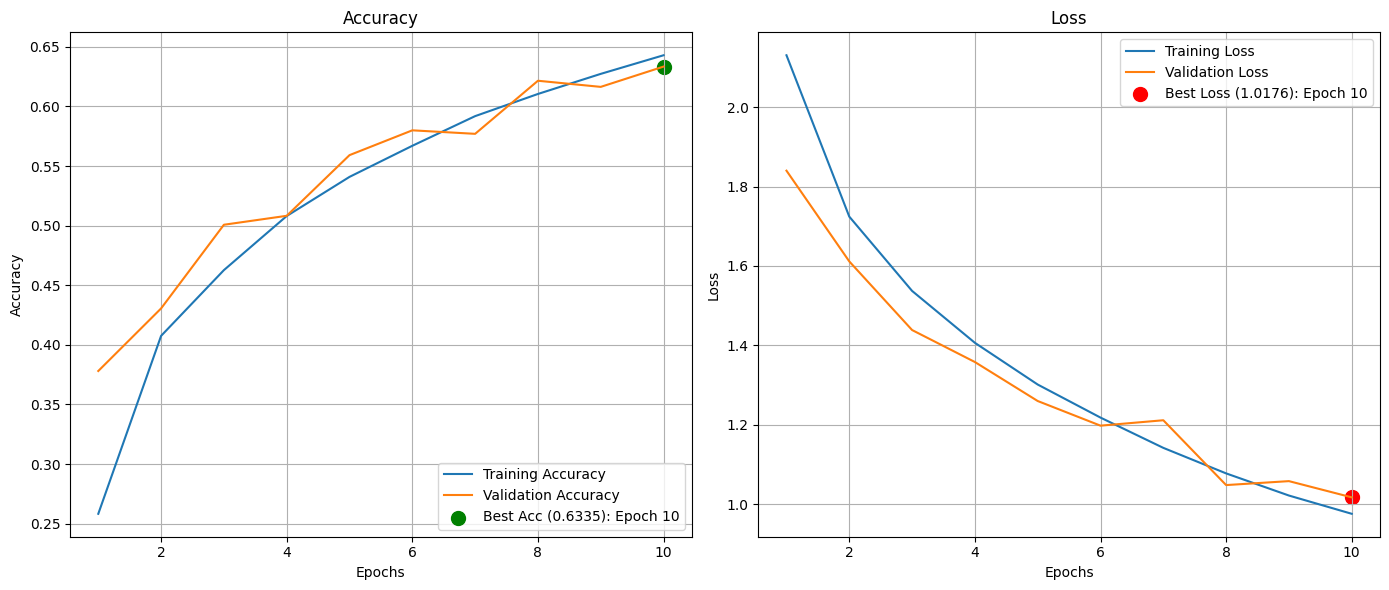

In [42]:
plot_learning_curves(history_viewcnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.63      0.93      0.75      4249
          06       0.00      0.00      0.00       401
          08       0.37      0.48      0.42      2748
          12       0.46      0.50      0.48      4633
          13       0.34      0.25      0.29      3429
          14       0.00      0.00      0.00      1139
          15       0.59      0.62      0.61      6421
          16       0.62      0.19      0.29      2061
          18       0.00      0.00      0.00      1058
          21       0.32      0.59      0.42      2899
          22       0.68      0.17      0.28       895
          23       0.44      0.62      0.52      2793
          27       0.94      0.33      0.49      1670
          30       0.94      0.32      0.47       803

    accuracy                           0.49     35199
   macro avg       0.45      0.36      0.36     35199
weighted avg       0.49      0.49      0.46     35

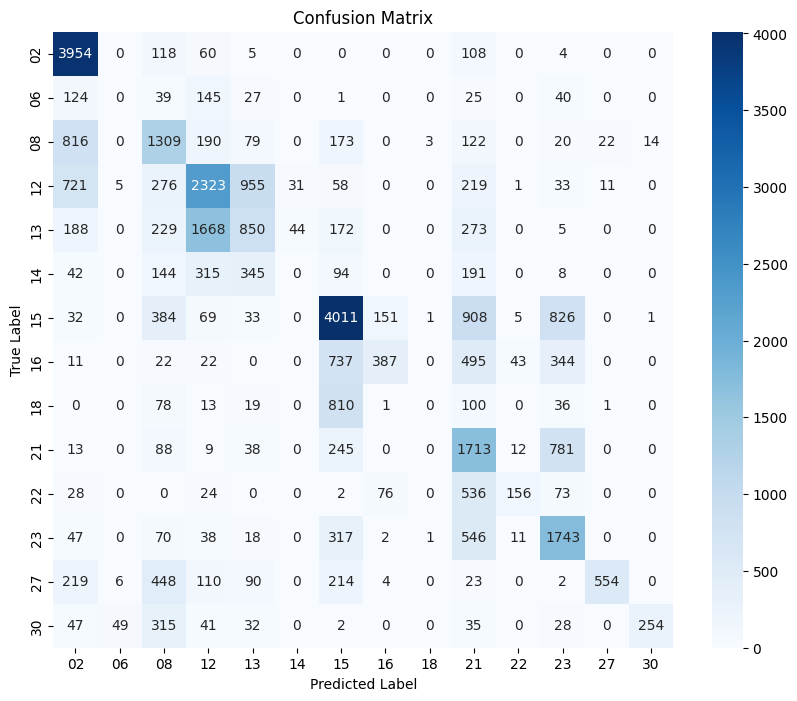

In [43]:
evaluate_model(trained_model_viewcnn, test_loader, base_dataset.classes)

In [44]:
save_model(trained_model_viewcnn, model_path_viewcnn, model_name_viewcnn)

Saved model weights for ViewCNN: ViewCNN.pth


### Load & Check Model

In [45]:
loaded_model_viewcnn = ViewCNN(num_classes=num_classes).to(DEVICE)

In [46]:
if not os.path.exists(BACKUP_DIR / model_path_viewcnn):
    raise FileNotFoundError(f"Model file not found: {model_path_viewcnn}")

In [ ]:
loaded_model_viewcnn.load_state_dict(torch.load(BACKUP_DIR / model_path_viewcnn))
loaded_model_viewcnn.eval()
evaluate_model(loaded_model_viewcnn, test_loader, base_dataset.classes)

## Optimized CNN

### Define Model

In [47]:
model_name_viewoptimizedcnn = "ViewOptimizedCNN"
model_path_viewoptimizedcnn = f"{model_name_viewoptimizedcnn}.pth"

In [48]:
class ViewOptimizedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ViewOptimizedCNN, self).__init__()
        
        # Block 1: Input (1, 224, 224) -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2: (32, 112, 112) -> (64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Block 3: (64, 56, 56) -> (128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Block 4: (128, 28, 28) -> (256, 14, 14)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc1 = nn.Linear(256, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

### Train & Save Model

In [49]:
model_viewoptimizedcnn = ViewOptimizedCNN(num_classes=num_classes).to(DEVICE)

criterion_viewoptimizedcnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_viewoptimizedcnn = optim.Adam(model_viewoptimizedcnn.parameters(), lr=1e-3)

num_epochs_viewoptimizedcnn = 10

In [50]:
trained_model_viewoptimizedcnn, history_viewoptimizedcnn = train_model(model_name=model_name_viewoptimizedcnn,
                                                                       model=model_viewoptimizedcnn,
                                                                       criterion=criterion_viewoptimizedcnn,
                                                                       optimizer=optimizer_viewoptimizedcnn,
                                                                       train_loader=train_loader,
                                                                       val_loader=val_loader,
                                                                       num_epochs=num_epochs_viewoptimizedcnn)

Starting training ViewOptimizedCNN model for 10 epochs...

Epoch 1/10:
Train Loss: 1.0695 Acc: 0.6009
Val Loss: 1.2403 Acc: 0.6082


Epoch 2/10:
Train Loss: 0.4686 Acc: 0.8238
Val Loss: 0.8122 Acc: 0.6631


Epoch 3/10:
Train Loss: 0.2872 Acc: 0.8930
Val Loss: 5.8819 Acc: 0.3002


Epoch 4/10:
Train Loss: 0.1924 Acc: 0.9299
Val Loss: 0.5832 Acc: 0.8040


Epoch 5/10:
Train Loss: 0.1403 Acc: 0.9481
Val Loss: 2.3683 Acc: 0.6497


Epoch 6/10:
Train Loss: 0.1154 Acc: 0.9581
Val Loss: 0.1608 Acc: 0.9400


Epoch 7/10:
Train Loss: 0.0973 Acc: 0.9638
Val Loss: 0.3970 Acc: 0.8750


Epoch 8/10:
Train Loss: 0.0807 Acc: 0.9699
Val Loss: 0.5723 Acc: 0.8032


Epoch 9/10:
Train Loss: 0.0749 Acc: 0.9719
Val Loss: 0.4674 Acc: 0.8588


Epoch 10/10:
Train Loss: 0.0655 Acc: 0.9749
Val Loss: 2.6716 Acc: 0.6406


Best Val Acc:   0.9400
Best Train Acc: 0.9749


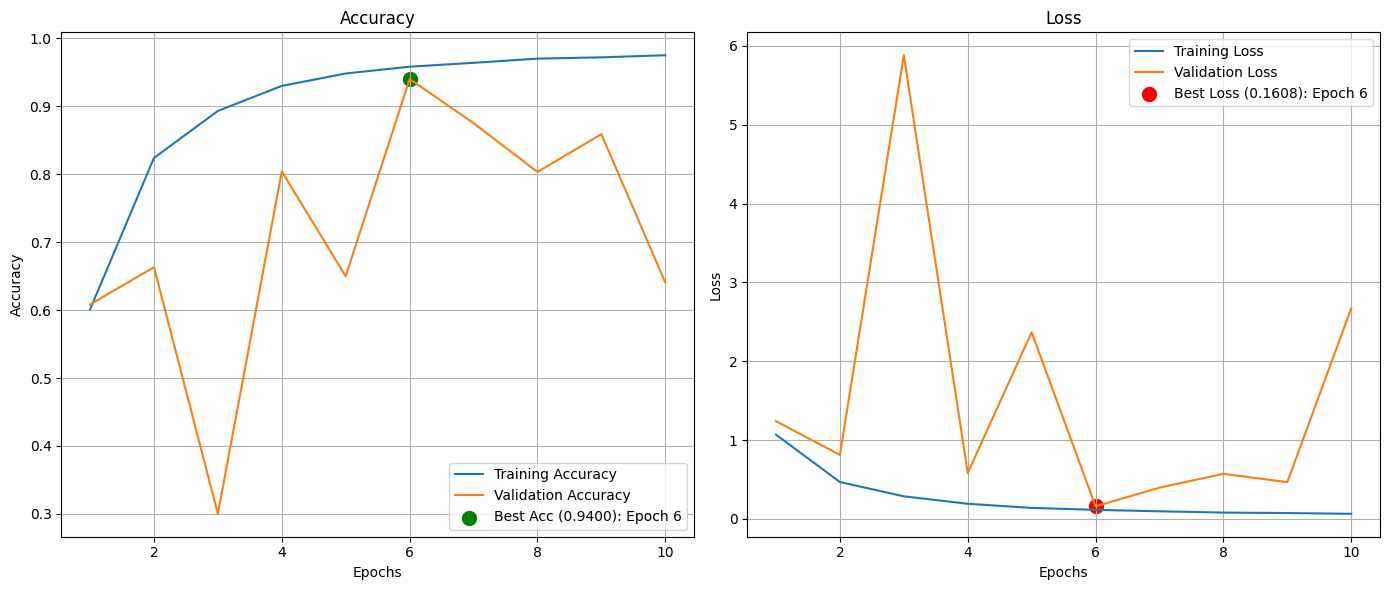

In [51]:
plot_learning_curves(history_viewoptimizedcnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.85      0.85      0.85      4249
          06       0.21      0.09      0.12       401
          08       0.84      0.30      0.44      2748
          12       0.58      0.38      0.46      4633
          13       0.36      0.67      0.47      3429
          14       0.14      0.10      0.12      1139
          15       0.78      0.73      0.75      6421
          16       0.42      0.76      0.54      2061
          18       0.30      0.02      0.04      1058
          21       0.66      0.46      0.54      2899
          22       0.21      0.41      0.28       895
          23       0.77      0.70      0.73      2793
          27       0.63      0.96      0.76      1670
          30       0.70      0.81      0.75       803

    accuracy                           0.59     35199
   macro avg       0.53      0.52      0.49     35199
weighted avg       0.63      0.59      0.58     35

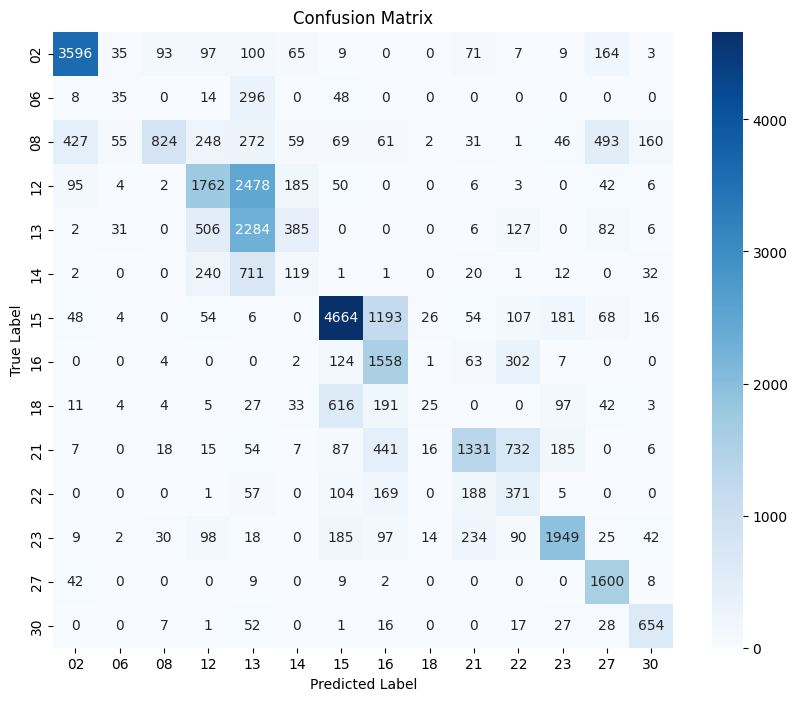

In [52]:
evaluate_model(trained_model_viewoptimizedcnn, test_loader, base_dataset.classes)

In [53]:
save_model(trained_model_viewoptimizedcnn, model_path_viewoptimizedcnn, model_name_viewoptimizedcnn)

Saved model weights for ViewOptimizedCNN: ViewOptimizedCNN.pth


### Load & Check Model

In [54]:
loaded_model_viewoptimizedcnn = ViewOptimizedCNN(num_classes=num_classes).to(DEVICE)

In [55]:
if not os.path.exists(BACKUP_DIR / model_path_viewoptimizedcnn):
    raise FileNotFoundError(f"Model file not found: {model_path_viewoptimizedcnn}")

In [ ]:
loaded_model_viewoptimizedcnn.load_state_dict(torch.load(BACKUP_DIR / model_path_viewoptimizedcnn))
loaded_model_viewoptimizedcnn.eval()
evaluate_model(loaded_model_viewoptimizedcnn, test_loader, base_dataset.classes)

## QNN (Hybrid)

### Define Model

In [56]:
n_qubits_qnn = 8
n_layers_qnn = 2

In [57]:
model_name_qnn = "HybridQNN"
model_path_qnn = f"{model_name_qnn}.pth"

In [58]:
# dev_qnn = qml.device('lightning.gpu', wires=n_qubits_qnn)
dev_qnn = qml.device('default.qubit', wires=n_qubits_qnn)

@qml.qnode(dev_qnn, interface='torch')
def quantum_circuit_qnn(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_qnn))
    
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_qnn))
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_qnn)]
    
weight_shapes_qnn = {"weights": (n_layers_qnn, n_qubits_qnn, 3)}

qlayer_qnn = qnn.TorchLayer(quantum_circuit_qnn, weight_shapes_qnn)

In [59]:
class HybridQNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fc1 = nn.Linear(32, n_qubits_qnn)
        self.qlayer = qlayer_qnn
        self.fc2 = nn.Linear(n_qubits_qnn, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = torch.tanh(x) * math.pi
        x = self.qlayer(x)
        x = self.fc2(x)
        return x

### Train & Save Model

In [60]:
model_qnn = HybridQNN(num_classes=num_classes).to(DEVICE)

criterion_qnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qnn = optim.Adam(model_qnn.parameters(), lr=1e-3)

num_epochs_qnn = 10

In [61]:
trained_model_qnn, history_qnn = train_model(model_name=model_name_qnn,
                                             model=model_qnn,
                                             criterion=criterion_qnn,
                                             optimizer=optimizer_qnn,
                                             train_loader=train_loader,
                                             val_loader=val_loader,
                                             num_epochs=num_epochs_qnn)

Starting training HybridQNN model for 10 epochs...

Epoch 1/10:
Train Loss: 2.5792 Acc: 0.1050
Val Loss: 2.3324 Acc: 0.1895


Epoch 2/10:
Train Loss: 2.0973 Acc: 0.2317
Val Loss: 1.9534 Acc: 0.2791


Epoch 3/10:
Train Loss: 1.8893 Acc: 0.2977
Val Loss: 1.7830 Acc: 0.3377


Epoch 4/10:
Train Loss: 1.7054 Acc: 0.3678
Val Loss: 1.6686 Acc: 0.4052


Epoch 5/10:
Train Loss: 1.5274 Acc: 0.4367
Val Loss: 1.4155 Acc: 0.4740


Epoch 6/10:
Train Loss: 1.3830 Acc: 0.4862
Val Loss: 1.3773 Acc: 0.4633


Epoch 7/10:
Train Loss: 1.2845 Acc: 0.5239
Val Loss: 1.3301 Acc: 0.5098


Epoch 8/10:
Train Loss: 1.2077 Acc: 0.5488
Val Loss: 1.2087 Acc: 0.5517


Epoch 9/10:
Train Loss: 1.1430 Acc: 0.5703
Val Loss: 1.1338 Acc: 0.5854


Epoch 10/10:
Train Loss: 1.0951 Acc: 0.5865
Val Loss: 1.0366 Acc: 0.5962


Best Val Acc:   0.5962
Best Train Acc: 0.5865


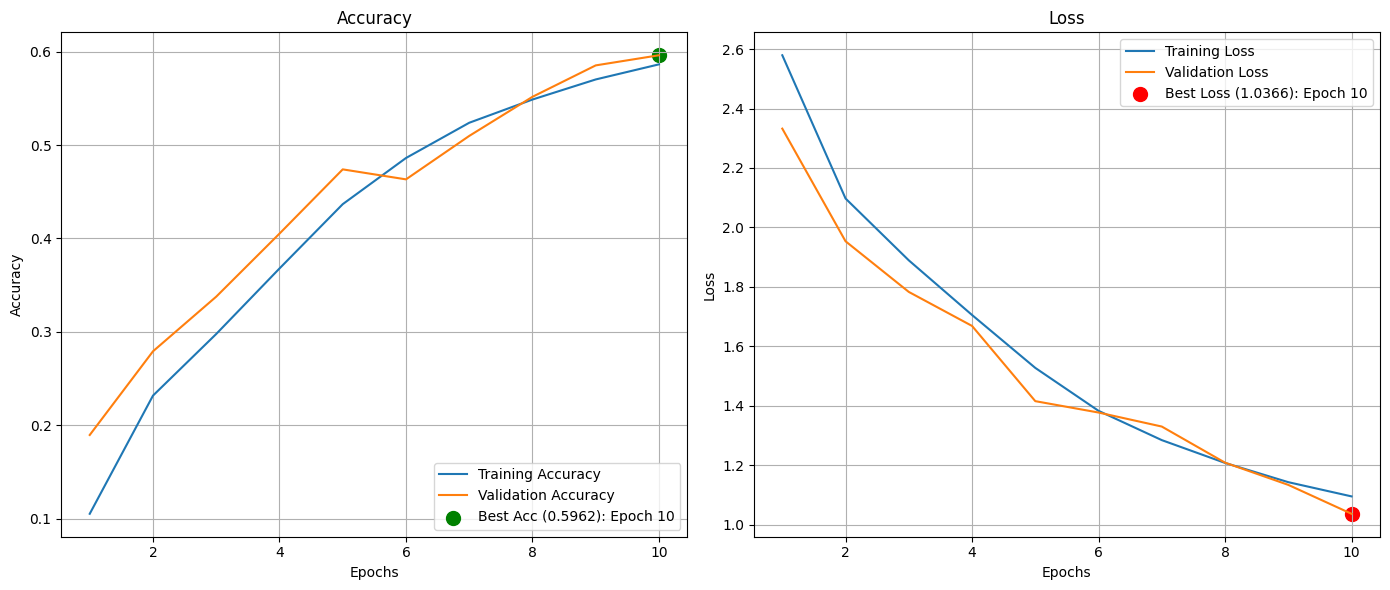

In [62]:
plot_learning_curves(history_qnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.82      0.81      0.82      4249
          06       0.01      0.02      0.02       401
          08       0.41      0.51      0.46      2748
          12       0.44      0.24      0.31      4633
          13       0.34      0.55      0.42      3429
          14       0.05      0.06      0.06      1139
          15       0.64      0.53      0.58      6421
          16       0.72      0.26      0.38      2061
          18       0.11      0.12      0.12      1058
          21       0.36      0.54      0.43      2899
          22       0.30      0.43      0.35       895
          23       0.28      0.30      0.29      2793
          27       0.70      0.59      0.64      1670
          30       0.78      0.35      0.48       803

    accuracy                           0.46     35199
   macro avg       0.43      0.38      0.38     35199
weighted avg       0.50      0.46      0.46     35

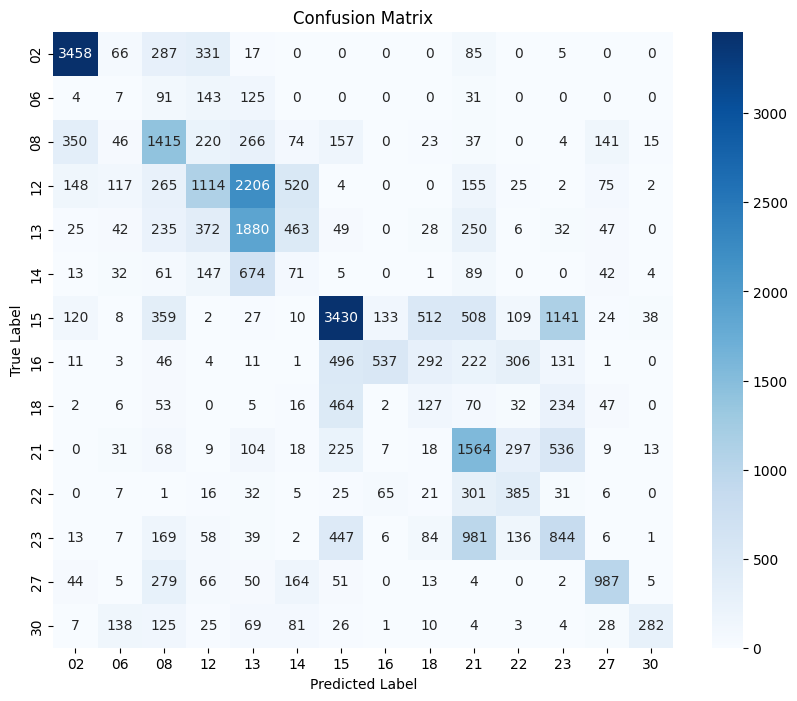

In [63]:
evaluate_model(trained_model_qnn, test_loader, base_dataset.classes)

In [64]:
save_model(trained_model_qnn, model_path_qnn, model_name_qnn)

Saved model weights for HybridQNN: HybridQNN.pth


### Load & Check Model

In [65]:
loaded_model_qnn = HybridQNN(num_classes=num_classes).to(DEVICE)

In [66]:
if not os.path.exists(BACKUP_DIR / model_path_qnn):
    raise FileNotFoundError(f"Model file not found: {model_path_qnn}")

In [ ]:
loaded_model_qnn.load_state_dict(torch.load(BACKUP_DIR / model_path_qnn))
loaded_model_qnn.eval()
evaluate_model(loaded_model_qnn, test_loader, base_dataset.classes)

## Optimized QNN (Hybrid)

### Define Model

In [67]:
n_qubits_optimizedqnn = 8
n_layers_optimizedqnn = 2

In [68]:
model_name_optimizedqnn = "HybridOptimizedQNN"
model_path_optimizedqnn = f"{model_name_optimizedqnn}.pth"

In [69]:
# dev_optimizedqnn  = qml.device('lightning.gpu', wires=n_qubits_optimizedqnn)
dev_optimizedqnn = qml.device('default.qubit', wires=n_qubits_optimizedqnn)

@qml.qnode(dev_optimizedqnn, interface='torch')
def quantum_circuit_optimizedqnn(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_optimizedqnn))
    
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_optimizedqnn))
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_optimizedqnn)]
    
weight_shapes_optimizedqnn = {"weights": (n_layers_optimizedqnn, n_qubits_optimizedqnn, 3)}

qlayer_optimizedqnn = qnn.TorchLayer(quantum_circuit_optimizedqnn, weight_shapes_optimizedqnn)

In [70]:
class ViewOptimizedQNN(nn.Module):
    def __init__(self, num_classes):
        super(ViewOptimizedQNN, self).__init__()
        
        # Block 1: Input (1, 224, 224) -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2: (32, 112, 112) -> (64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Block 3: (64, 56, 56) -> (128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Block 4: (128, 28, 28) -> (256, 14, 14)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc1 = nn.Linear(256, 512)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()
        self.fc_to_q = nn.Linear(512, n_qubits_optimizedqnn)
        self.qlayer = qlayer_optimizedqnn
        self.fc_out = nn.Linear(n_qubits_optimizedqnn, num_classes)
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        
        x = self.fc_to_q(x)
        x = torch.tanh(x) * math.pi
        x = self.qlayer(x)
        x = self.fc_out(x)
        
        return x

### Train & Save Model

In [71]:
model_optimizedqnn = ViewOptimizedQNN(num_classes=num_classes).to(DEVICE)

criterion_optimizedqnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_optimizedqnn = optim.Adam(model_optimizedqnn.parameters(), lr=1e-3)

num_epochs_optimizedqnn = 10

In [72]:
trained_model_optimizedqnn, history_optimizedqnn = train_model(model_name=model_name_optimizedqnn,
                                                               model=model_optimizedqnn,
                                                               criterion=criterion_optimizedqnn,
                                                               optimizer=optimizer_optimizedqnn,
                                                               train_loader=train_loader,
                                                               val_loader=val_loader,
                                                               num_epochs=num_epochs_optimizedqnn)

Starting training HybridOptimizedQNN model for 10 epochs...

Epoch 1/10:
Train Loss: 2.0173 Acc: 0.2373
Val Loss: 1.9399 Acc: 0.2716


Epoch 2/10:
Train Loss: 1.4213 Acc: 0.4072
Val Loss: 1.4021 Acc: 0.4349


Epoch 3/10:
Train Loss: 0.9936 Acc: 0.6212
Val Loss: 0.9079 Acc: 0.6801


Epoch 4/10:
Train Loss: 0.7088 Acc: 0.7235
Val Loss: 1.2080 Acc: 0.6155


Epoch 5/10:
Train Loss: 0.5536 Acc: 0.7776
Val Loss: 0.7991 Acc: 0.7012


Epoch 6/10:
Train Loss: 0.4318 Acc: 0.8230
Val Loss: 0.5142 Acc: 0.8305


Epoch 7/10:
Train Loss: 0.3521 Acc: 0.8511
Val Loss: 0.2856 Acc: 0.8874


Epoch 8/10:
Train Loss: 0.2968 Acc: 0.8740
Val Loss: 0.2946 Acc: 0.8769


Epoch 9/10:
Train Loss: 0.2576 Acc: 0.8937
Val Loss: 0.3060 Acc: 0.8954


Epoch 10/10:
Train Loss: 0.2225 Acc: 0.9129
Val Loss: 0.5174 Acc: 0.8523


Best Val Acc:   0.8954
Best Train Acc: 0.9129


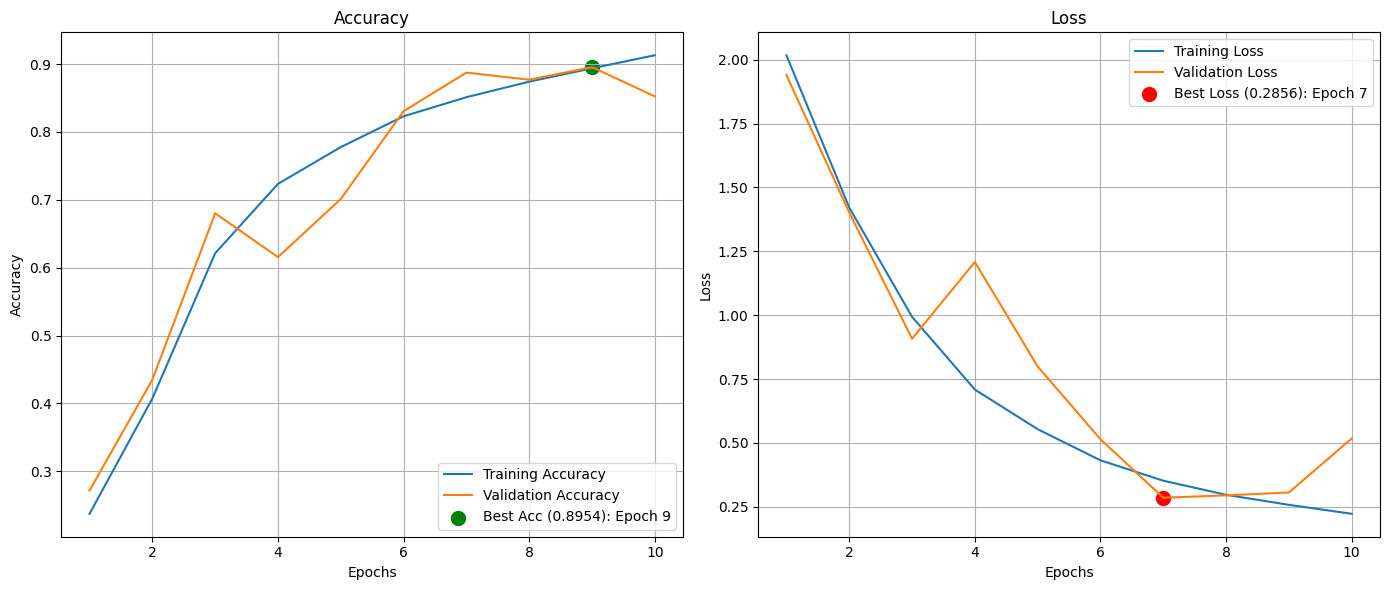

In [73]:
plot_learning_curves(history_optimizedqnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.68      0.92      0.79      4249
          06       0.00      0.00      0.00       401
          08       0.76      0.40      0.53      2748
          12       0.51      0.68      0.59      4633
          13       0.55      0.45      0.50      3429
          14       0.17      0.07      0.10      1139
          15       0.53      0.87      0.66      6421
          16       0.60      0.29      0.39      2061
          18       0.06      0.09      0.07      1058
          21       0.75      0.26      0.39      2899
          22       0.11      0.02      0.04       895
          23       0.56      0.42      0.48      2793
          27       0.74      0.82      0.78      1670
          30       0.89      0.50      0.64       803

    accuracy                           0.56     35199
   macro avg       0.49      0.41      0.42     35199
weighted avg       0.57      0.56      0.53     35

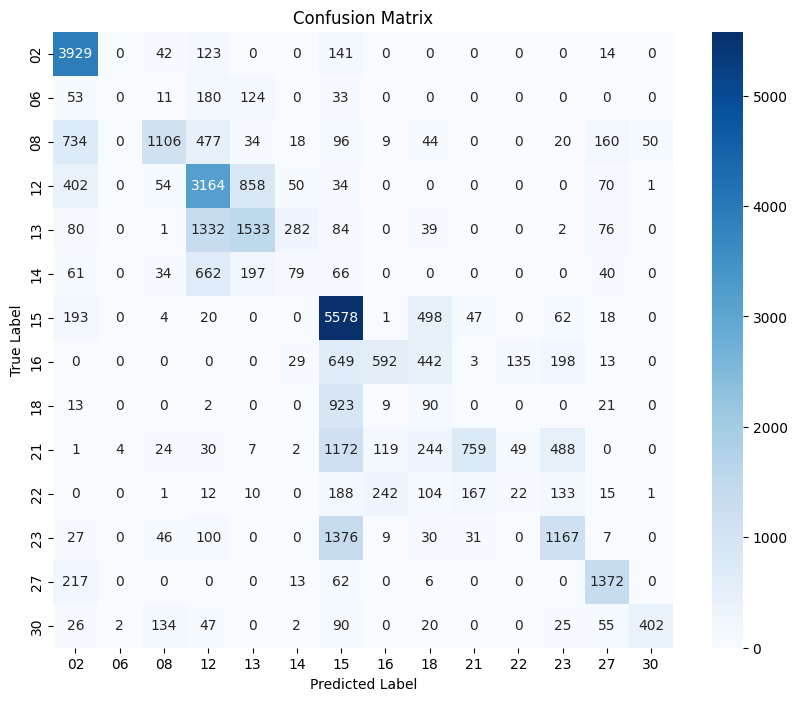

In [74]:
evaluate_model(trained_model_optimizedqnn, test_loader, base_dataset.classes)

In [75]:
save_model(trained_model_optimizedqnn, model_path_optimizedqnn, model_name_optimizedqnn)

Saved model weights for HybridOptimizedQNN: HybridOptimizedQNN.pth


### Load & Check Model

In [76]:
loaded_model_optimizedqnn = ViewOptimizedQNN(num_classes=num_classes).to(DEVICE)

In [77]:
if not os.path.exists(BACKUP_DIR / model_path_optimizedqnn):
    raise FileNotFoundError(f"Model file not found: {model_path_optimizedqnn}")

In [ ]:
loaded_model_optimizedqnn.load_state_dict(torch.load(BACKUP_DIR / model_path_optimizedqnn))
loaded_model_optimizedqnn.eval()
evaluate_model(loaded_model_optimizedqnn, test_loader, base_dataset.classes)

## ResNet + Classical Head

### Define Model

In [38]:
n_hidden_resnetchead = 8

In [39]:
model_name_resnetchead = "ResNetClassicalHead"
model_path_resnetchead = f"{model_name_resnetchead}.pth"

In [40]:
class ResNetClassicalHead(nn.Module):
    def __init__(self, base_model, num_classes):
        super().__init__()
        self.base = base_model
        in_features = self.base.fc.in_features
        self.base.fc = nn.Identity()
        self.fc1 = nn.Linear(in_features, n_hidden_resnetchead)
        self.fc_out = nn.Linear(n_hidden_resnetchead, num_classes)

    def forward(self, x):
        x = self.base(x)
        x = self.fc1(x)
        x = torch.tanh(x) 
        x = self.fc_out(x)
        return x

In [41]:
backbone_resnetchead = models.resnet18(weights=None)
backbone_resnetchead.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

### Train & Save Model

In [42]:
model_resnetchead = ResNetClassicalHead(base_model=backbone_resnetchead, num_classes=num_classes).to(DEVICE)

criterion_resnetchead = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_resnetchead = optim.Adam(model_resnetchead.parameters(), lr=1e-3)

num_epochs_resnetchead = 10

In [43]:
trained_model_resnetchead, history_resnetchead = train_model(model_name=model_name_resnetchead,
                                                             model=model_resnetchead,
                                                             criterion=criterion_resnetchead,
                                                             optimizer=optimizer_resnetchead,
                                                             train_loader=train_loader,
                                                             val_loader=val_loader,
                                                             num_epochs=num_epochs_resnetchead)

Starting training ResNetClassicalHead model for 10 epochs...

Epoch 1/10:
Train Loss: 0.6787 Acc: 0.7697
Val Loss: 0.3148 Acc: 0.8875


Epoch 2/10:
Train Loss: 0.1385 Acc: 0.9493
Val Loss: 0.0614 Acc: 0.9780


Epoch 3/10:
Train Loss: 0.0654 Acc: 0.9777
Val Loss: 0.0410 Acc: 0.9859


Epoch 4/10:
Train Loss: 0.0432 Acc: 0.9826
Val Loss: 0.0756 Acc: 0.9637


Epoch 5/10:
Train Loss: 0.0328 Acc: 0.9853
Val Loss: 0.0847 Acc: 0.9752


Epoch 6/10:
Train Loss: 0.0284 Acc: 0.9862
Val Loss: 0.0648 Acc: 0.9790


Epoch 7/10:
Train Loss: 0.0246 Acc: 0.9872
Val Loss: 0.0233 Acc: 0.9859


Epoch 8/10:
Train Loss: 0.0218 Acc: 0.9884
Val Loss: 0.0170 Acc: 0.9892


Epoch 9/10:
Train Loss: 0.0218 Acc: 0.9878
Val Loss: 0.0183 Acc: 0.9890


Epoch 10/10:
Train Loss: 0.0188 Acc: 0.9889
Val Loss: 0.0159 Acc: 0.9900


Best Val Acc:   0.9900
Best Train Acc: 0.9889


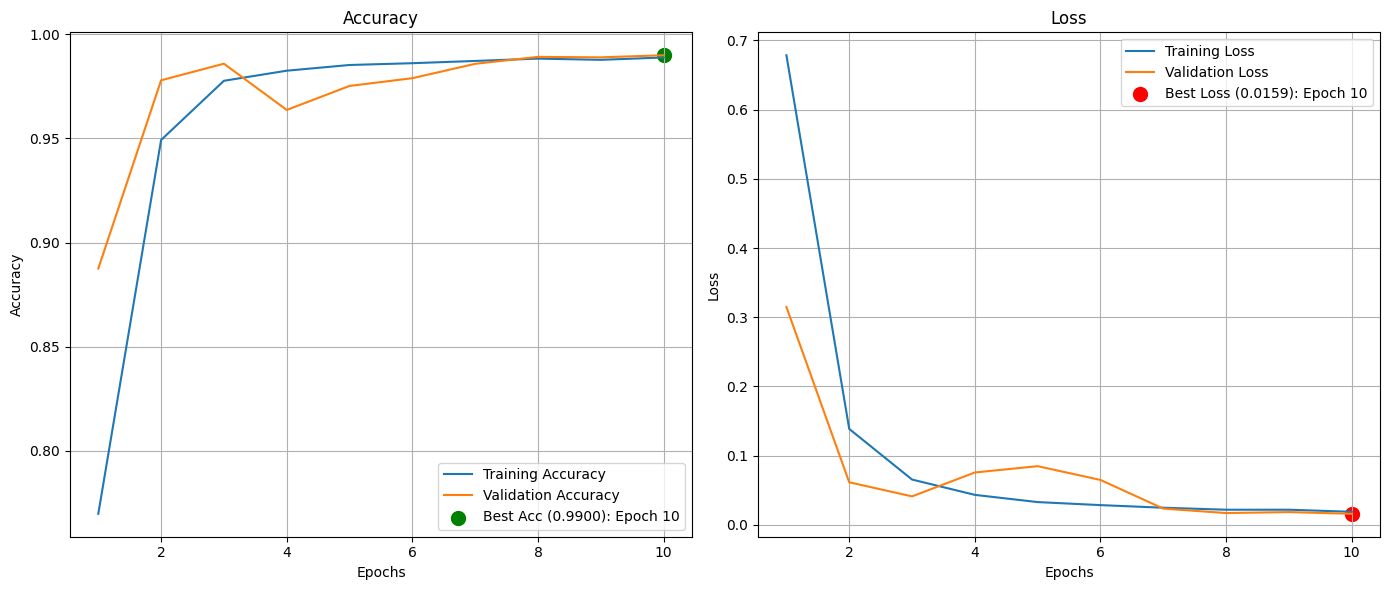

In [44]:
plot_learning_curves(history_resnetchead)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.85      0.94      0.90      4249
          06       0.48      0.08      0.13       401
          08       0.91      0.83      0.87      2748
          12       0.60      0.63      0.61      4633
          13       0.50      0.47      0.48      3429
          14       0.15      0.11      0.13      1139
          15       0.86      0.90      0.88      6421
          16       0.77      0.73      0.75      2061
          18       0.60      0.67      0.63      1058
          21       0.68      0.73      0.70      2899
          22       0.51      0.34      0.41       895
          23       0.85      0.88      0.86      2793
          27       0.95      0.89      0.92      1670
          30       0.81      0.97      0.88       803

    accuracy                           0.74     35199
   macro avg       0.68      0.66      0.65     35199
weighted avg       0.73      0.74      0.73     35

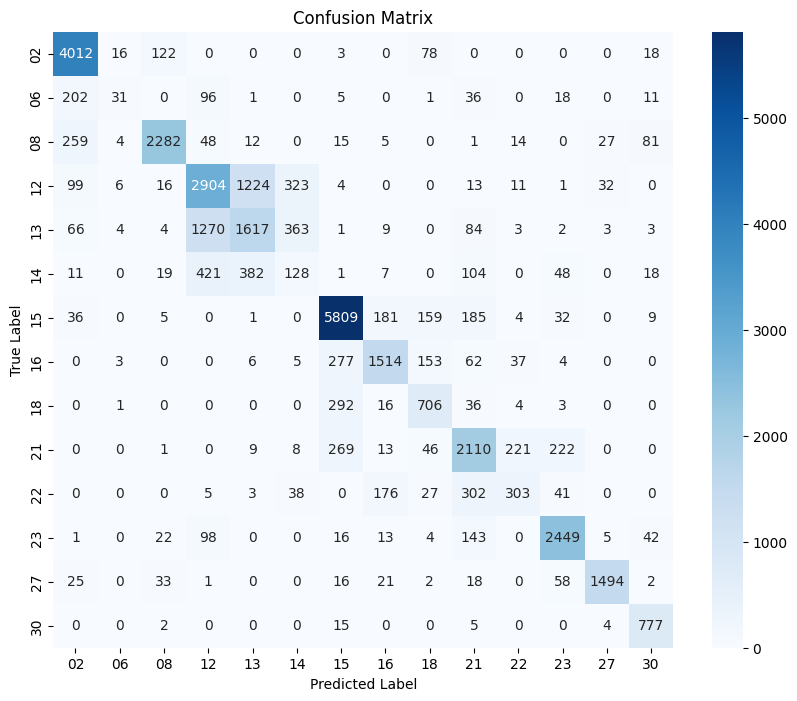

In [45]:
evaluate_model(trained_model_resnetchead, test_loader, base_dataset.classes)

In [46]:
save_model(trained_model_resnetchead, model_path_resnetchead, model_name_resnetchead)

Saved model weights for ResNetClassicalHead: ResNetClassicalHead.pth


## Optimized ResNet

### Define Model

In [38]:
model_name_viewoptimizedresnet = "ViewOptimizedResNet"
model_path_viewoptimizedresnet = f"{model_name_viewoptimizedresnet}.pth"

In [38]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        
        # First convolution
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second convolution
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

In [40]:
class ViewOptimizedResNet(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(ViewOptimizedResNet, self).__init__()
        
        # Initial Convolution
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet Layers
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial processing
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual Layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Output Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

### Train & Save Model

In [41]:
model_viewoptimizedresnet = ViewOptimizedResNet(num_classes=num_classes).to(DEVICE)

criterion_viewoptimizedresnet = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_viewoptimizedresnet = optim.Adam(model_viewoptimizedresnet.parameters(), lr=1e-3)

num_epochs_viewoptimizedresnet = 10

In [42]:
trained_model_viewoptimizedresnet, history_viewoptimizedresnet = train_model(model_name=model_name_viewoptimizedresnet,
                                                                             model=model_viewoptimizedresnet,
                                                                             criterion=criterion_viewoptimizedresnet,
                                                                             optimizer=optimizer_viewoptimizedresnet,
                                                                             train_loader=train_loader,
                                                                             val_loader=val_loader,
                                                                             num_epochs=num_epochs_viewoptimizedresnet)

Starting training ViewOptimizedResNet model for 10 epochs...

Epoch 1/10:
Train Loss: 0.2569 Acc: 0.9065
Val Loss: 1.2256 Acc: 0.7510


Epoch 2/10:
Train Loss: 0.0539 Acc: 0.9788
Val Loss: 0.0279 Acc: 0.9859


Epoch 3/10:
Train Loss: 0.0326 Acc: 0.9846
Val Loss: 0.0234 Acc: 0.9871


Epoch 4/10:
Train Loss: 0.0276 Acc: 0.9859
Val Loss: 0.0227 Acc: 0.9870


Epoch 5/10:
Train Loss: 0.0224 Acc: 0.9871
Val Loss: 0.0261 Acc: 0.9858


Epoch 6/10:
Train Loss: 0.0207 Acc: 0.9881
Val Loss: 0.0231 Acc: 0.9858


Epoch 7/10:
Train Loss: 0.0187 Acc: 0.9889
Val Loss: 0.0143 Acc: 0.9896


Epoch 8/10:
Train Loss: 0.0183 Acc: 0.9885
Val Loss: 0.0141 Acc: 0.9904


Epoch 9/10:
Train Loss: 0.0176 Acc: 0.9893
Val Loss: 0.0170 Acc: 0.9888


Epoch 10/10:
Train Loss: 0.0169 Acc: 0.9890
Val Loss: 0.0133 Acc: 0.9904


Best Val Acc:   0.9904
Best Train Acc: 0.9893


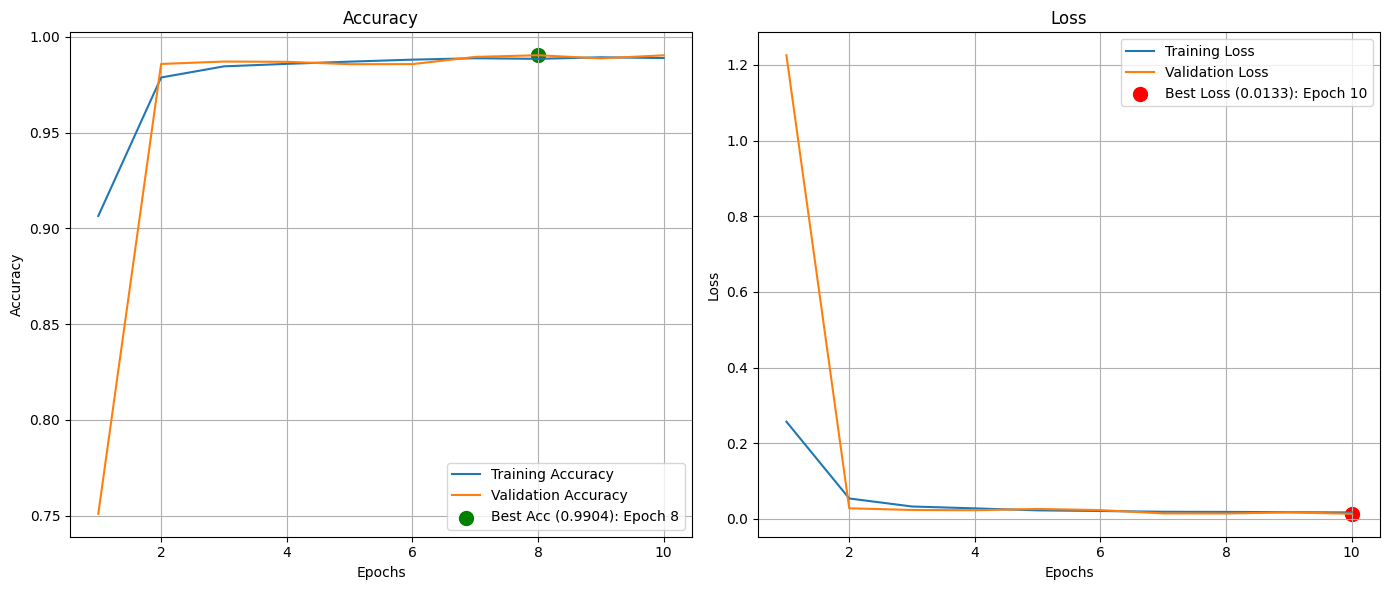

In [43]:
plot_learning_curves(history_viewoptimizedresnet)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.94      0.94      0.94      4249
          06       1.00      0.34      0.51       401
          08       0.76      0.88      0.81      2748
          12       0.65      0.61      0.63      4633
          13       0.46      0.64      0.53      3429
          14       0.59      0.09      0.15      1139
          15       0.85      0.92      0.88      6421
          16       0.72      0.66      0.68      2061
          18       0.73      0.71      0.72      1058
          21       0.81      0.76      0.79      2899
          22       0.72      0.54      0.62       895
          23       0.89      0.87      0.88      2793
          27       0.91      0.87      0.89      1670
          30       0.99      0.84      0.91       803

    accuracy                           0.77     35199
   macro avg       0.79      0.69      0.71     35199
weighted avg       0.77      0.77      0.76     35

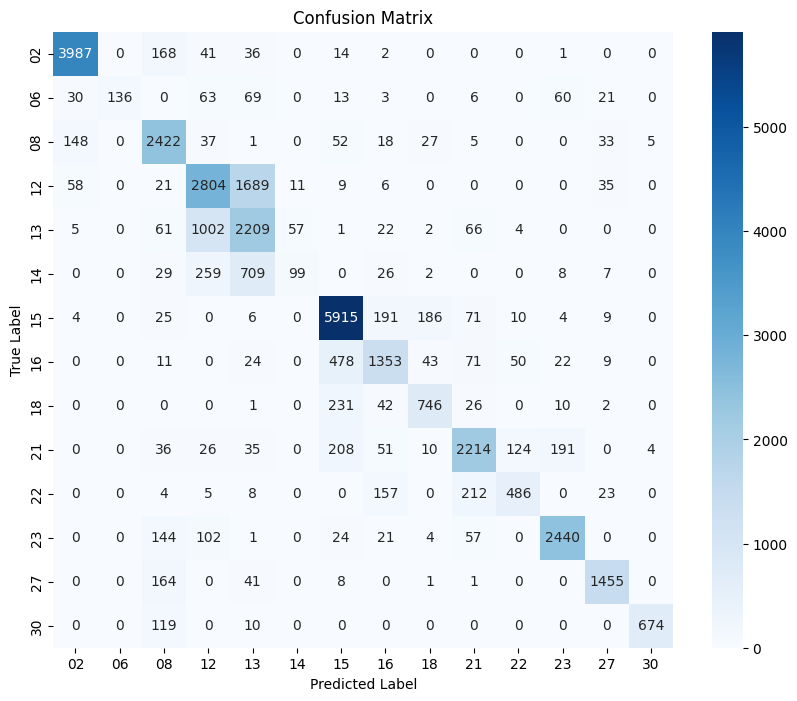

In [44]:
evaluate_model(trained_model_viewoptimizedresnet, test_loader, base_dataset.classes)

In [45]:
save_model(trained_model_viewoptimizedresnet, model_path_viewoptimizedresnet, model_name_viewoptimizedresnet)

Saved model weights for ViewOptimizedResNet: ViewOptimizedResNet.pth


### Load & Check Model

In [46]:
loaded_model_viewoptimizedresnet = ViewOptimizedResNet(num_classes=num_classes).to(DEVICE)

In [47]:
if not os.path.exists(BACKUP_DIR / model_path_viewoptimizedresnet):
    raise FileNotFoundError(f"Model file not found: {model_path_viewoptimizedresnet}")

In [ ]:
loaded_model_viewoptimizedresnet.load_state_dict(torch.load(BACKUP_DIR / model_path_viewoptimizedresnet))
loaded_model_viewoptimizedresnet.eval()
evaluate_model(loaded_model_viewoptimizedresnet, test_loader, base_dataset.classes)

## Optimized ResNet (KFold)

In [ ]:
cv_results = cross_validate_model(
    model_class=ViewOptimizedResNet,
    train_dataset=base_dataset,
    num_epochs=10,
    k_folds=5,
    num_workers=NUM_WORKERS
)

In [ ]:
print("Classification Report for all Folds:")
for i in range(5):
    loaded_model_fold = ViewOptimizedResNet(num_classes=num_classes).to(DEVICE)
    model_path_fold = f"ViewOptimizedResNet_Fold{i+1}.pth"

    if not os.path.exists(BACKUP_DIR / model_path_fold):
        raise FileNotFoundError(f"Model file not found: {model_path_fold}")

    print(f"   FOLD {i+1}:")
    loaded_model_fold.load_state_dict(torch.load(BACKUP_DIR / model_path_fold))
    loaded_model_fold.eval()
    evaluate_model(loaded_model_fold, test_loader, base_dataset.classes)

## ResNet (Hybrid) + Quantum Head

### Define Model

In [67]:
n_qubits_qresnetqhead = 8
n_layers_qresnetqhead = 2

In [68]:
model_name_qresnetqhead = "ResNetQuantumHead"
model_path_qresnetqhead = f"{model_name_qresnetqhead}.pth"

In [69]:
dev_qresnetqhead = qml.device('default.qubit', wires=n_qubits_qresnetqhead)

@qml.qnode(dev_qresnetqhead, interface='torch')
def quantum_circuit_qresnetqhead(inputs, weights):

    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_qresnetqhead))

    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_qresnetqhead))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_qresnetqhead)]
    
weight_shapes_qresnetqhead = {'weights': (n_layers_qresnetqhead, n_qubits_qresnetqhead, 3)}

qlayer_qresnetqhead = qnn.TorchLayer(quantum_circuit_qresnetqhead, weight_shapes_qresnetqhead)

In [70]:
class ResNetQuantumHead(nn.Module):
    def __init__(self, base_model, num_classes):
        super().__init__()
        self.base = base_model
        in_features = self.base.fc.in_features
        self.base.fc = nn.Identity()
        self.fc1 = nn.Linear(in_features, n_qubits_qresnetqhead)
        self.q_layer = qlayer_qresnetqhead
        self.fc_out = nn.Linear(n_qubits_qresnetqhead, num_classes)

    def forward(self, x):
        x = self.base(x)
        x = self.fc1(x)
        x = torch.tanh(x) * math.pi
        x = self.q_layer(x)
        x = self.fc_out(x)
        return x

In [71]:
backbone_optimizedqresnet = models.resnet18(weights=None)
backbone_optimizedqresnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

### Train & Save Model

In [72]:
model_qresnetqhead = ResNetQuantumHead(base_model=backbone_optimizedqresnet, num_classes=num_classes).to(DEVICE)

criterion_qresnetqhead = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qresnetqhead = optim.Adam(model_qresnetqhead.parameters(), lr=1e-3)

num_epochs_qresnetqhead = 10

In [73]:
trained_model_qresnetqhead, history_qresnetqhead = train_model(model_name=model_name_qresnetqhead,
                                                               model=model_qresnetqhead,
                                                               criterion=criterion_qresnetqhead,
                                                               optimizer=optimizer_qresnetqhead,
                                                               train_loader=train_loader,
                                                               val_loader=val_loader,
                                                               num_epochs=num_epochs_qresnetqhead)

Starting training ResNetQuantumHead model for 10 epochs...

Epoch 1/10:
Train Loss: 2.0576 Acc: 0.2287
Val Loss: 1.5221 Acc: 0.4401


Epoch 2/10:
Train Loss: 1.3258 Acc: 0.5122
Val Loss: 0.8639 Acc: 0.6981


Epoch 3/10:
Train Loss: 0.4361 Acc: 0.8393
Val Loss: 0.1893 Acc: 0.9550


Epoch 4/10:
Train Loss: 0.1324 Acc: 0.9691
Val Loss: 0.1325 Acc: 0.9643


Epoch 5/10:
Train Loss: 0.0702 Acc: 0.9820
Val Loss: 0.7706 Acc: 0.8161


Epoch 6/10:
Train Loss: 0.0455 Acc: 0.9854
Val Loss: 0.0409 Acc: 0.9856


Epoch 7/10:
Train Loss: 0.0370 Acc: 0.9863
Val Loss: 0.0335 Acc: 0.9859


Epoch 8/10:
Train Loss: 0.0298 Acc: 0.9876
Val Loss: 0.0352 Acc: 0.9868


Epoch 9/10:
Train Loss: 0.0251 Acc: 0.9886
Val Loss: 0.0709 Acc: 0.9750


Epoch 10/10:
Train Loss: 0.0241 Acc: 0.9887
Val Loss: 0.0190 Acc: 0.9890


Best Val Acc:   0.9890
Best Train Acc: 0.9887


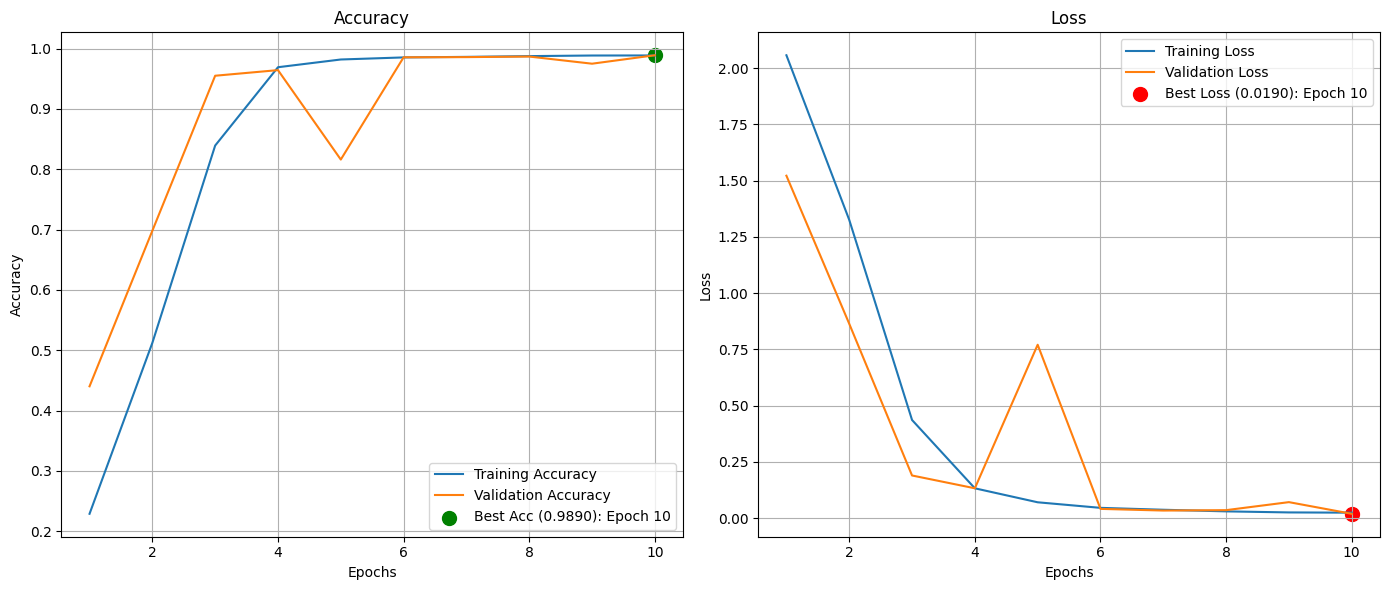

In [74]:
plot_learning_curves(history_qresnetqhead)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.93      0.87      0.90      4249
          06       0.44      0.28      0.34       401
          08       0.79      0.79      0.79      2748
          12       0.54      0.61      0.57      4633
          13       0.49      0.56      0.52      3429
          14       0.19      0.10      0.13      1139
          15       0.84      0.85      0.84      6421
          16       0.55      0.76      0.64      2061
          18       0.56      0.52      0.54      1058
          21       0.81      0.72      0.77      2899
          22       0.68      0.37      0.48       895
          23       0.80      0.78      0.79      2793
          27       0.82      0.86      0.84      1670
          30       0.98      0.75      0.85       803

    accuracy                           0.71     35199
   macro avg       0.67      0.63      0.64     35199
weighted avg       0.72      0.71      0.71     35

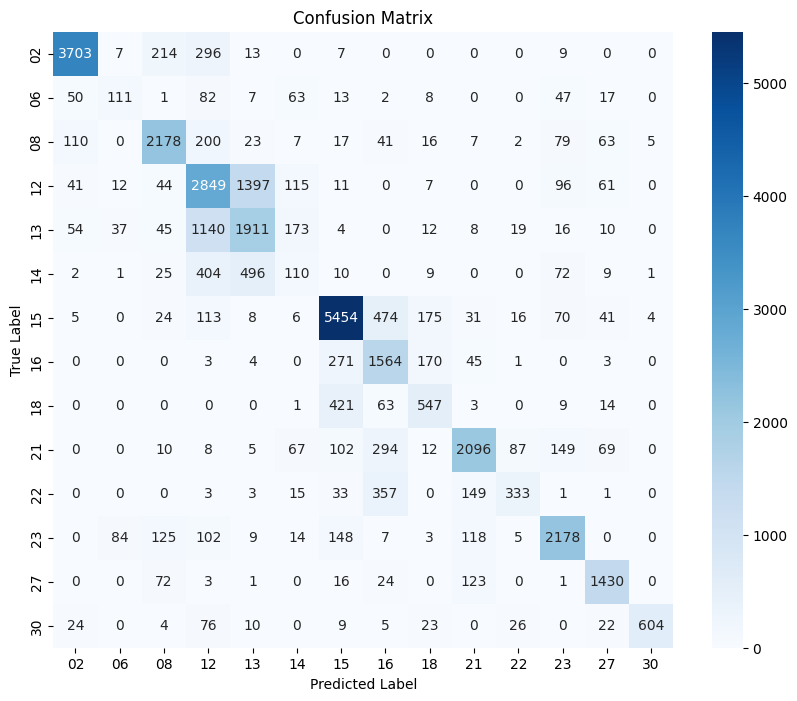

In [75]:
evaluate_model(trained_model_qresnetqhead, test_loader, base_dataset.classes)

In [76]:
save_model(trained_model_qresnetqhead, model_path_qresnetqhead, model_name_qresnetqhead)

Saved model weights for ResNetQuantumHead: ResNetQuantumHead.pth


## Optimized QResNet

### Define Model

In [48]:
n_qubits_optimizedqresnet = 10
n_layers_optimizedqresnet = 4

In [49]:
model_name_optimizedqresnet = "ViewOptimizedQResNet"
model_path_optimizedqresnet = f"{model_name_optimizedqresnet}.pth"

In [50]:
dev_optimizedqresnet = qml.device('default.qubit', wires=n_qubits_optimizedqresnet)
# dev_optimizedqresnet = qml.device('lightning.gpu', wires=n_qubits_optimizedqresnet)

@qml.qnode(dev_optimizedqresnet, interface='torch')
def quantum_circuit_optimizedqresnet(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_optimizedqresnet))
    
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_optimizedqresnet))
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_optimizedqresnet)]
    
weight_shapes_optimizedqresnet = {"weights": (n_layers_optimizedqresnet, n_qubits_optimizedqresnet, 3)}

qlayer_optimizedqresnet = qnn.TorchLayer(quantum_circuit_optimizedqresnet, weight_shapes_optimizedqresnet)

In [51]:
class ViewOptimizedQResNet(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(ViewOptimizedQResNet, self).__init__()
        
        # Initial Convolution
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet Layers
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc_to_q = nn.Linear(512, n_qubits_optimizedqresnet)
        self.qlayer = qlayer_optimizedqresnet
        self.fc_out = nn.Linear(n_qubits_optimizedqresnet, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial processing
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual Layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Output Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        
        # Quantum Block
        x = self.fc_to_q(x)
        x = torch.tanh(x) * math.pi
        x = self.qlayer(x)
        x = self.fc_out(x)

        return x

### Train & Save Model

In [52]:
model_optimizedqresnet = ViewOptimizedQResNet(num_classes=num_classes).to(DEVICE)

criterion_optimizedqresnet = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_optimizedqresnet = optim.Adam(model_optimizedqresnet.parameters(), lr=1e-3)

num_epochs_optimizedqresnet = 10

In [53]:
trained_model_optimizedqresnet, history_optimizedqresnet = train_model(model_name=model_name_optimizedqresnet,
                                                                       model=model_optimizedqresnet,
                                                                       criterion=criterion_optimizedqresnet,
                                                                       optimizer=optimizer_optimizedqresnet,
                                                                       train_loader=train_loader,
                                                                       val_loader=val_loader,
                                                                       num_epochs=num_epochs_optimizedqresnet)

Starting training ViewOptimizedQResNet model for 10 epochs...

Epoch 1/10:
Train Loss: 1.9352 Acc: 0.2091
Val Loss: 1.4476 Acc: 0.3638


Epoch 2/10:
Train Loss: 0.8472 Acc: 0.6590
Val Loss: 0.3878 Acc: 0.8313


Epoch 3/10:
Train Loss: 0.3344 Acc: 0.8377
Val Loss: 0.3474 Acc: 0.8327


Epoch 4/10:
Train Loss: 0.2540 Acc: 0.8773
Val Loss: 0.1851 Acc: 0.9316


Epoch 5/10:
Train Loss: 0.1455 Acc: 0.9562
Val Loss: 0.1013 Acc: 0.9828


Epoch 6/10:
Train Loss: 0.0806 Acc: 0.9825
Val Loss: 0.0622 Acc: 0.9866


Epoch 7/10:
Train Loss: 0.0488 Acc: 0.9867
Val Loss: 0.0343 Acc: 0.9884


Epoch 8/10:
Train Loss: 0.0342 Acc: 0.9876
Val Loss: 0.0272 Acc: 0.9865


Epoch 9/10:
Train Loss: 0.0264 Acc: 0.9883
Val Loss: 0.0248 Acc: 0.9882


Epoch 10/10:
Train Loss: 0.0229 Acc: 0.9888
Val Loss: 0.0212 Acc: 0.9886


Best Val Acc:   0.9886
Best Train Acc: 0.9888


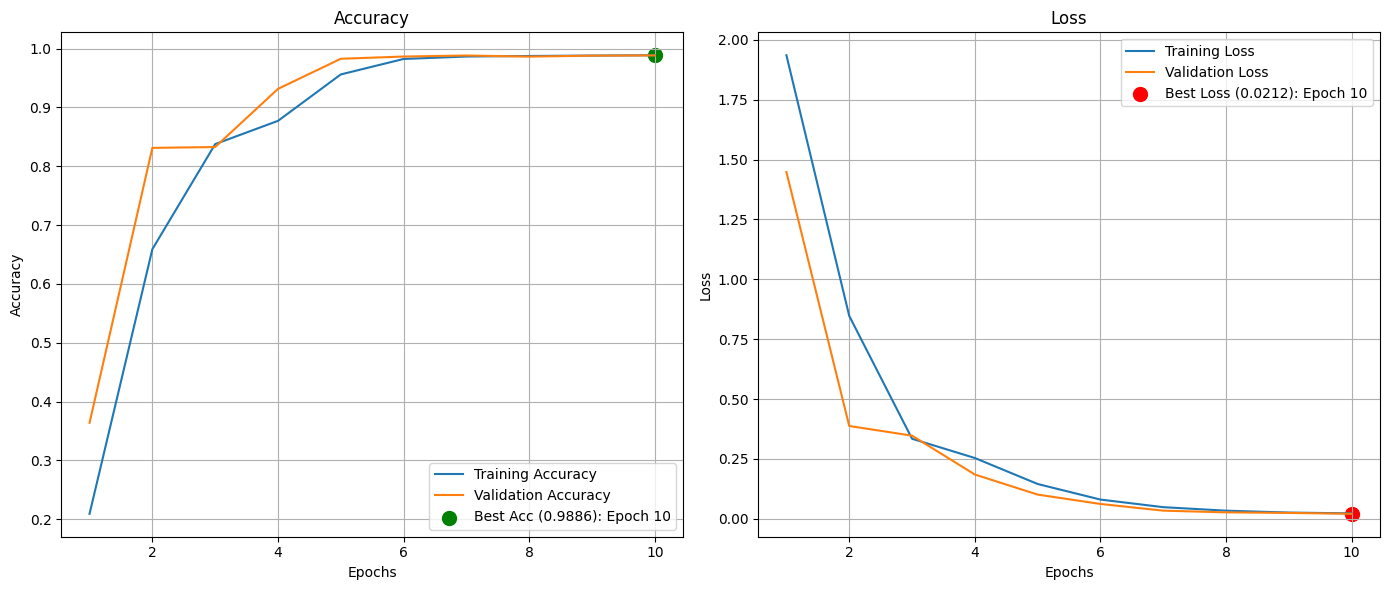

In [54]:
plot_learning_curves(history_optimizedqresnet)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.94      0.86      0.90      4249
          06       0.53      0.22      0.31       401
          08       0.85      0.84      0.84      2748
          12       0.56      0.63      0.59      4633
          13       0.53      0.55      0.54      3429
          14       0.25      0.15      0.19      1139
          15       0.81      0.90      0.85      6421
          16       0.69      0.62      0.65      2061
          18       0.44      0.39      0.41      1058
          21       0.80      0.81      0.80      2899
          22       0.58      0.54      0.56       895
          23       0.96      0.81      0.87      2793
          27       0.70      0.98      0.82      1670
          30       0.98      0.75      0.85       803

    accuracy                           0.73     35199
   macro avg       0.69      0.65      0.66     35199
weighted avg       0.73      0.73      0.73     35

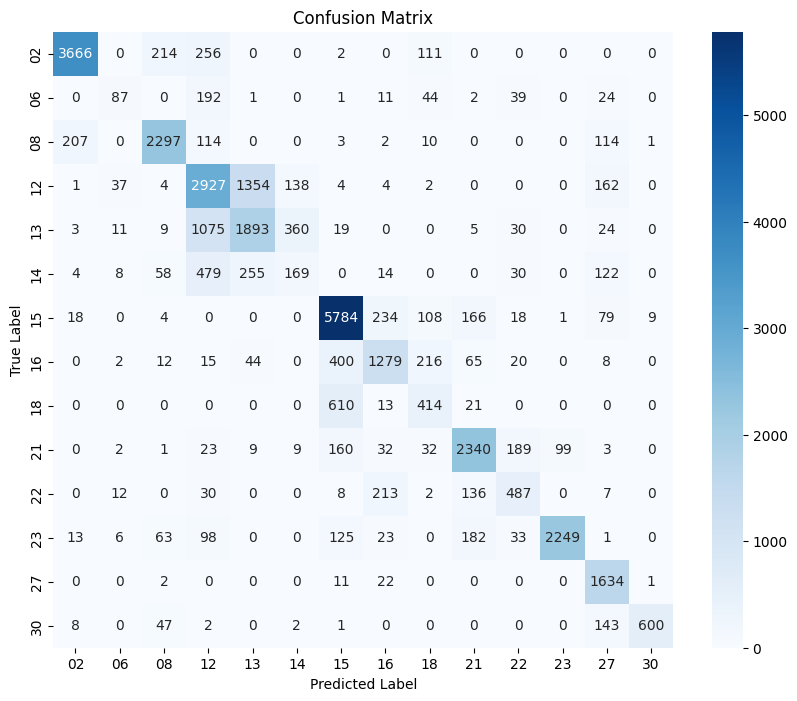

In [55]:
evaluate_model(trained_model_optimizedqresnet, test_loader, base_dataset.classes)

In [56]:
save_model(trained_model_optimizedqresnet, model_path_optimizedqresnet, model_name_optimizedqresnet)

Saved model weights for ViewOptimizedQResNet: ViewOptimizedQResNet.pth


### Load & Check Model

In [57]:
loaded_model_optimizedqresnet = ViewOptimizedQResNet(num_classes=num_classes).to(DEVICE)

In [58]:
if not os.path.exists(BACKUP_DIR / model_path_optimizedqresnet):
    raise FileNotFoundError(f"Model file not found: {model_path_optimizedqresnet}")

In [ ]:
loaded_model_optimizedqresnet.load_state_dict(torch.load(BACKUP_DIR / model_path_optimizedqresnet))
loaded_model_optimizedqresnet.eval()
evaluate_model(loaded_model_optimizedqresnet, test_loader, base_dataset.classes)

## Quantum Hopfield Network

### Define Model

In [98]:
# Modern Hopfield Layer
class ModernHopfieldLayer(nn.Module):
    """
    Modern Hopfield Network layer (continuous formulation).

    Uses exponential interaction functions (softmax attention) for
    associative pattern retrieval, achieving exponentially large storage
    capacity compared to classical Hopfield nets.

    Each stored pattern acts as a learnable class prototype.  During the
    forward pass the layer computes:
        attention = softmax(beta * Q @ K^T)   (over stored patterns)
        retrieved = attention @ V
        output    = LayerNorm(Q + retrieved)   (residual connection)

    Reference
    ---------
    Ramsauer et al., "Hopfield Networks is All You Need", ICLR 2021.
    """

    def __init__(
        self,
        input_dim: int,
        num_stored_patterns: int,
        pattern_dim: int,
        num_heads: int = 4,
        beta_init: float = 1.0,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.num_stored_patterns = num_stored_patterns
        self.pattern_dim = pattern_dim
        self.num_heads = num_heads
        self.head_dim = pattern_dim // num_heads
        assert pattern_dim % num_heads == 0, "pattern_dim must be divisible by num_heads"

        # Learnable Inverse-Temperature (Sharpness of Attention)
        self.beta = nn.Parameter(torch.tensor(beta_init))

        # Learnable Stored Patterns (The Associative Memory)
        self.stored_patterns = nn.Parameter(
            torch.randn(num_stored_patterns, pattern_dim) * 0.02
        )

        # Multi-Head Projections
        self.query_proj = nn.Linear(input_dim, pattern_dim)
        self.key_proj   = nn.Linear(pattern_dim, pattern_dim)
        self.value_proj = nn.Linear(pattern_dim, pattern_dim)
        self.out_proj   = nn.Linear(pattern_dim, pattern_dim)

        # Stability Helpers
        self.layer_norm = nn.LayerNorm(pattern_dim)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        """
        Parameters
        ----------
        x : Tensor of shape (batch_size, input_dim)

        Returns
        -------
        output            : Tensor (batch_size, pattern_dim)
        attention_weights : Tensor (batch_size, num_heads, num_stored_patterns)
        """
        B = x.size(0)
        H = self.num_heads
        D = self.head_dim
        N = self.num_stored_patterns

        # Project Input -> Query
        query = self.query_proj(x) # (B, pattern_dim)

        # Keys and Values from Stored Patterns
        keys   = self.key_proj(self.stored_patterns)   # (N, pattern_dim)
        values = self.value_proj(self.stored_patterns) # (N, pattern_dim)

        # Reshape for Multi-Head Attention
        query  = query.view(B, H, D)                   # (B, H, D)
        keys   = keys.view(N, H, D).permute(1, 2, 0)   # (H, D, N)
        values = values.view(N, H, D).permute(1, 0, 2) # (H, N, D)

        # Scaled Dot-Product Attention with Learnable Temperature
        attn_logits = torch.einsum("bhd,hdn->bhn", query, keys) # (B, H, N)
        attn_logits = self.beta * attn_logits / (D ** 0.5)
        attn_weights = F.softmax(attn_logits, dim=-1)           # (B, H, N)
        attn_weights = self.dropout(attn_weights)

        # Retrieve Patterns
        retrieved = torch.einsum("bhn,hnd->bhd", attn_weights, values) # (B, H, D)
        retrieved = retrieved.reshape(B, -1)                           # (B, pattern_dim)
        retrieved = self.out_proj(retrieved)

        # Residual Connection + LayerNorm
        output = self.layer_norm(query.reshape(B, -1) + retrieved)

        return output, attn_weights

In [99]:
n_qubits_qhopfield = 10
n_layers_qhopfield = 4

In [100]:
model_name_qhopfield = "ResNetQuantumHopfield"
model_path_qhopfield = f"{model_name_qhopfield}.pth"

In [101]:
dev_qhopfield = qml.device("default.qubit", wires=n_qubits_qhopfield)

@qml.qnode(dev_qhopfield, interface="torch")
def quantum_circuit_qhopfield(inputs, weights_entangle, weights_ry):
    """
    Enhanced variational quantum circuit for Hopfield refinement.

    1. AngleEmbedding            - encode classical features into qubit rotations
    2. StronglyEntanglingLayers  - create rich entanglement structure
    3. Extra RY rotations        - additional expressivity (learnable bias)
    """
    
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_qhopfield))

    qml.templates.StronglyEntanglingLayers(weights_entangle, wires=range(n_qubits_qhopfield))

    # Extra Single-Qubit Rotations (Bias-Like)
    for i in range(n_qubits_qhopfield):
        qml.RY(weights_ry[i], wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_qhopfield)]

weight_shapes_qhopfield = {"weights_entangle": (n_layers_qhopfield, n_qubits_qhopfield, 3),
                           "weights_ry":       (n_qubits_qhopfield,)}

qlayer_qhopfield = qnn.TorchLayer(quantum_circuit_qhopfield, weight_shapes_qhopfield)

In [102]:
class ResNetQuantumHopfield(nn.Module):
    """
    Hybrid architecture that chains:
        ResNet-18 backbone
          -> FC projection
          -> Modern Hopfield associative memory
          -> Quantum variational refinement
          -> Classification head

    The Hopfield layer learns N stored patterns (prototypes) per class
    and retrieves the best match via attention.  The quantum circuit then
    applies entanglement-based non-linear mixing to the retrieved
    representation before the final classifier.
    """

    def __init__(
        self,
        base_model: nn.Module,
        num_classes: int,
        hopfield_dim: int = 128,
        num_prototypes_per_class: int = 4,
        hopfield_heads: int = 4,
        hopfield_beta: float = 2.0,
        dropout: float = 0.3,
    ):
        super().__init__()

        # ResNet Backbone
        self.base = base_model
        in_features = self.base.fc.in_features # Typically 512 for ResNet-18
        self.base.fc = nn.Identity()

        # Project ResNet Features -> Hopfield Input Space
        self.fc_proj = nn.Sequential(
            nn.Linear(in_features, hopfield_dim),
            nn.BatchNorm1d(hopfield_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Modern Hopfield Layer
        num_stored = num_classes * num_prototypes_per_class
        self.hopfield = ModernHopfieldLayer(
            input_dim=hopfield_dim,
            num_stored_patterns=num_stored,
            pattern_dim=hopfield_dim,
            num_heads=hopfield_heads,
            beta_init=hopfield_beta,
            dropout=dropout,
        )

        # Bridge: Hopfield Output -> Quantum Input
        self.fc_to_q = nn.Sequential(
            nn.Linear(hopfield_dim, n_qubits_qhopfield),
            nn.Tanh(),  # squash into [-1, 1] for angle encoding
        )

        # Quantum Refinement Layer
        self.q_layer = qlayer_qhopfield

        # Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits_qhopfield, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ResNet Feature Extraction
        features = self.base(x) # (B, 512)

        # Project to Hopfield Space
        h = self.fc_proj(features) # (B, hopfield_dim)

        # Hopfield Associative Retrieval
        h, _attn = self.hopfield(h) # (B, hopfield_dim)

        # Bridge to Quantum
        q_input = self.fc_to_q(h) * math.pi # (B, n_qubits) scaled to [-pi, pi]

        # Quantum Refinement
        q_output = self.q_layer(q_input) # (B, n_qubits)

        # Classify
        logits = self.classifier(q_output) # (B, num_classes)
        return logits

In [103]:
backbone_qhopfield = models.resnet18(weights=None)
backbone_qhopfield.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

### Train & Save Model

In [104]:
model_qhopfield = ResNetQuantumHopfield(base_model=backbone_qhopfield,
                                        num_classes=num_classes,
                                        hopfield_dim=128,
                                        num_prototypes_per_class=4, # 4 prototypes x 14 classes = 56 stored patterns
                                        hopfield_heads=4,
                                        hopfield_beta=2.0,
                                        dropout=0.3,).to(DEVICE)

criterion_qhopfield = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
optimizer_qhopfield = optim.AdamW(model_qhopfield.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs_qhopfield = 10

In [105]:
trained_model_qhopfield, history_qhopfield = train_model(model_name=model_name_qhopfield,
                                                         model=model_qhopfield,
                                                         criterion=criterion_qhopfield,
                                                         optimizer=optimizer_qhopfield,
                                                         train_loader=train_loader,
                                                         val_loader=val_loader,
                                                         num_epochs=num_epochs_qhopfield)

Starting training ResNetQuantumHopfield model for 10 epochs...

Epoch 1/10:
Train Loss: 2.3124 Acc: 0.1796
Val Loss: 1.8860 Acc: 0.4228


Epoch 2/10:
Train Loss: 1.4554 Acc: 0.5860
Val Loss: 1.7995 Acc: 0.5170


Epoch 3/10:
Train Loss: 0.9318 Acc: 0.8481
Val Loss: 0.7720 Acc: 0.9068


Epoch 4/10:
Train Loss: 0.7831 Acc: 0.9242
Val Loss: 0.6708 Acc: 0.9679


Epoch 5/10:
Train Loss: 0.7013 Acc: 0.9664
Val Loss: 0.7637 Acc: 0.9319


Epoch 6/10:
Train Loss: 0.6723 Acc: 0.9760
Val Loss: 0.6255 Acc: 0.9809


Epoch 7/10:
Train Loss: 0.6547 Acc: 0.9805
Val Loss: 0.6013 Acc: 0.9895


Epoch 8/10:
Train Loss: 0.6454 Acc: 0.9825
Val Loss: 0.6134 Acc: 0.9854


Epoch 9/10:
Train Loss: 0.6359 Acc: 0.9852
Val Loss: 0.6116 Acc: 0.9858


Epoch 10/10:
Train Loss: 0.6373 Acc: 0.9845
Val Loss: 0.6039 Acc: 0.9873


Best Val Acc:   0.9895
Best Train Acc: 0.9852


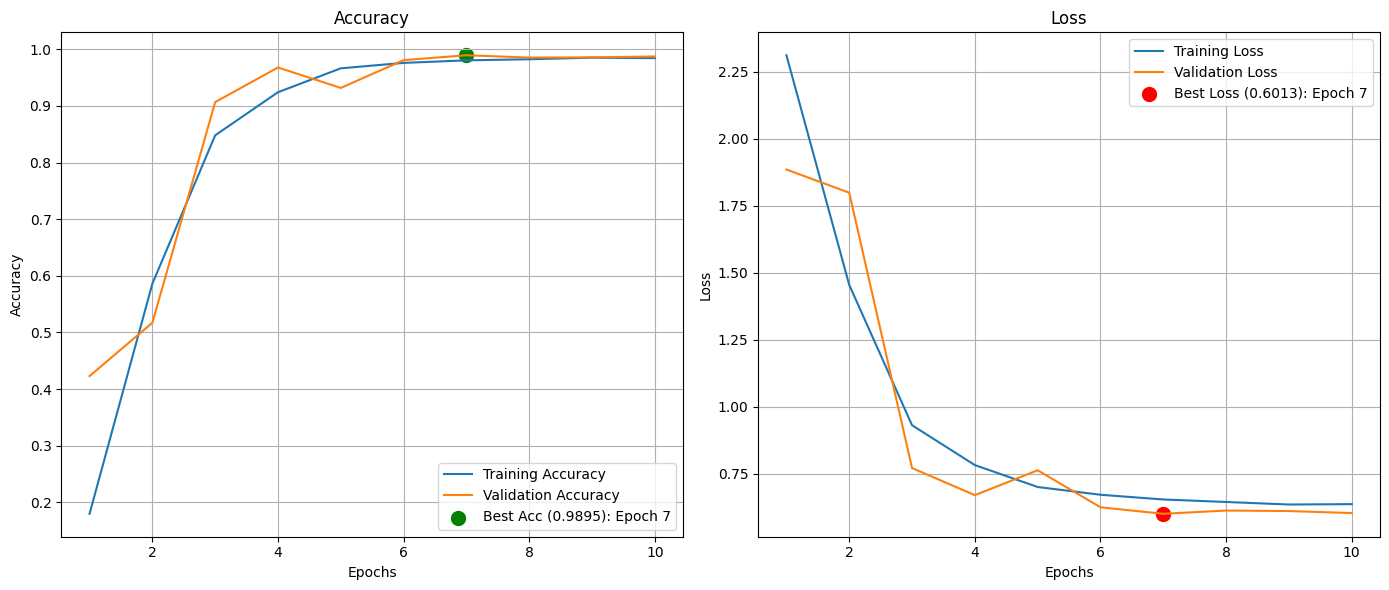

In [106]:
plot_learning_curves(history_qhopfield)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.93      0.91      0.92      4249
          06       0.46      0.22      0.30       401
          08       0.82      0.85      0.83      2748
          12       0.56      0.59      0.58      4633
          13       0.45      0.59      0.51      3429
          14       0.15      0.06      0.09      1139
          15       0.80      0.89      0.84      6421
          16       0.70      0.72      0.71      2061
          18       0.68      0.44      0.54      1058
          21       0.86      0.72      0.78      2899
          22       0.84      0.57      0.68       895
          23       0.81      0.82      0.82      2793
          27       0.85      0.85      0.85      1670
          30       0.88      0.75      0.81       803

    accuracy                           0.73     35199
   macro avg       0.70      0.64      0.66     35199
weighted avg       0.73      0.73      0.72     35

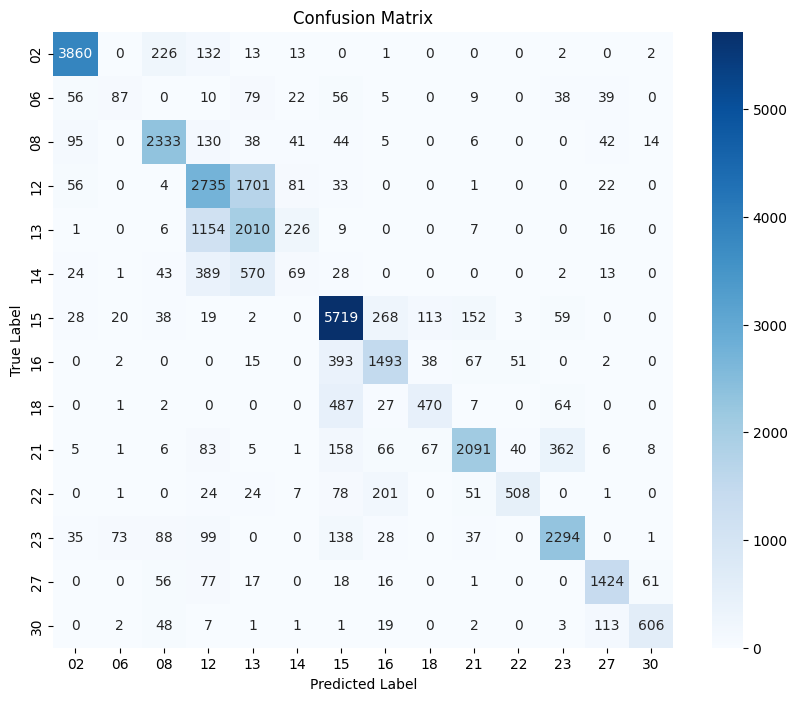

In [107]:
evaluate_model(trained_model_qhopfield, test_loader, base_dataset.classes)

In [108]:
save_model(trained_model_qhopfield, model_path_qhopfield, model_name_qhopfield)

Saved model weights for ResNetQuantumHopfield: ResNetQuantumHopfield.pth


## Quantum-Classical Dual-Path Network

### Define Model

In [38]:
class FocalLoss_dp(nn.Module):
    """
    Focal Loss (Lin et al., 2017) – down-weights easy examples so the
    model concentrates on the confused classes (15/23, 12/13, etc.).

        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets,
                                  weight=self.weight,
                                  reduction='none',
                                  label_smoothing=self.label_smoothing)
        
        pt = torch.exp(-ce_loss) # p_t for each sample
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

In [39]:
aug_tf_dp = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(20),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
    ]),
    
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])
}

In [40]:
train_data_aug_dp = TransformedSubset(train_subset, transform=aug_tf_dp['train'])
val_data_aug_dp   = TransformedSubset(val_subset,   transform=aug_tf_dp['val'])

train_loader_aug_dp = DataLoader(train_data_aug_dp, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader_aug_dp   = DataLoader(val_data_aug_dp,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Augmented data: Train: {len(train_data_aug_dp)}; Validation: {len(val_data_aug_dp)}")

Augmented data: Train: 140115; Validation: 35029


In [41]:
n_qubits_dp = 8
n_layers_dp = 3

In [42]:
model_name_dp = "DualPathQuantumNet"
model_path_dp = f"{model_name_dp}.pth"

In [43]:
dev_dp = qml.device("default.qubit", wires=n_qubits_dp)

@qml.qnode(dev_dp, interface="torch")
def quantum_circuit_dp(inputs, weights_ent, weights_ry):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_dp))
    
    qml.templates.StronglyEntanglingLayers(weights_ent, wires=range(n_qubits_dp))
    
    for i in range(n_qubits_dp):
        qml.RY(weights_ry[i], wires=i)
        
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_dp)]

qlayer_dp = qnn.TorchLayer(quantum_circuit_dp, {"weights_ent": (n_layers_dp, n_qubits_dp, 3),
                                                "weights_ry":  (n_qubits_dp,)})

In [44]:
class DualPathQuantumNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Pretrained ResNet-18, Adapted For 1-Channel
        backbone = models.resnet18(weights='IMAGENET1K_V1')
        # Adapt First Conv: Average RGB -> Grayscale
        orig_w = backbone.conv1.weight.data # (64, 3, 7, 7)
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        backbone.conv1.weight.data = orig_w.mean(dim=1, keepdim=True) # (64, 1, 7, 7)
        in_features = backbone.fc.in_features # 512
        backbone.fc = nn.Identity()

        # Freeze Early Layers For Faster Convergence & Less Overfitting
        for name, param in backbone.named_parameters():
            if 'layer1' in name or 'conv1' in name or 'bn1' in name:
                param.requires_grad = False

        self.backbone = backbone

        # Classical Path
        self.classical = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.4),
        )

        # Quantum Path
        self.q_bridge = nn.Sequential(
            nn.Linear(in_features, n_qubits_dp),
            nn.Tanh(),
        )
        self.q_layer = qlayer_dp
        self.q_expand = nn.Sequential(
            nn.Linear(n_qubits_dp, 64),
            nn.GELU(),
        )

        # Fusion + Classifier
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(256 + 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256 + 64, num_classes),
        )

    def forward(self, x):
        feat = self.backbone(x)                 # (B, 512)

        # Classical Path
        c_out = self.classical(feat)             # (B, 256)

        # Quantum Path
        q_in  = self.q_bridge(feat) * math.pi    # (B, 8)
        q_out = self.q_layer(q_in)               # (B, 8)
        q_out = self.q_expand(q_out)             # (B, 64)

        # Fuse and Classify
        fused = torch.cat([c_out, q_out], dim=1) # (B, 320)
        return self.classifier(fused)            # (B, num_classes)

### Train & Save Model

In [45]:
def train_model_dp(model_name, model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs):
    """Enhanced training loop with LR scheduling."""
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    print(f"Training {model_name} for {num_epochs} epochs...")
    print(f"   LR schedule: CosineAnnealing, Initial LR = {optimizer.param_groups[0]['lr']}")
    print()

    for epoch in range(num_epochs):
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{num_epochs}  (lr={lr_now:.6f}):")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc  = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"   {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        # Step The Scheduler After Each Epoch
        scheduler.step()
        print()

    print(f"Best Val Acc: {best_val_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history

In [46]:
model_dp = DualPathQuantumNet(num_classes=num_classes).to(DEVICE)

num_epochs_dp = 15

criterion_dp = FocalLoss_dp(weight=class_weights_tensor, gamma=2.0, label_smoothing=0.1)
optimizer_dp = optim.AdamW(model_dp.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_dp = CosineAnnealingLR(optimizer_dp, T_max=num_epochs_dp, eta_min=1e-6)

In [47]:
total_p     = sum(p.numel() for p in model_dp.parameters())
trainable_p = sum(p.numel() for p in model_dp.parameters() if p.requires_grad)
frozen_p    = total_p - trainable_p

print(f"Model: {model_name_dp}")
print(f"   Total params:     {total_p:,}")
print(f"   Trainable params: {trainable_p:,}")
print(f"   Frozen params:    {frozen_p:,}")
print(f"   Quantum: {n_qubits_dp} qubits, {n_layers_dp} layers")
print(f"   Loss: FocalLoss_dp(gamma=2, smoothing=0.1)")
print(f"   Augmentation: flip/rotate/affine/erase")

Model: DualPathQuantumNet
   Total params:     11,311,974
   Trainable params: 6,512,294
   Frozen params:    4,799,680
   Quantum: 8 qubits, 3 layers
   Loss: FocalLoss_dp(gamma=2, smoothing=0.1)
   Augmentation: flip/rotate/affine/erase


In [48]:
trained_model_dp, history_dp = train_model_dp(model_name=model_name_dp,
                                              model=model_dp,
                                              criterion=criterion_dp,
                                              optimizer=optimizer_dp,
                                              scheduler=scheduler_dp,
                                              train_loader=train_loader_aug_dp,
                                              val_loader=val_loader_aug_dp,
                                              num_epochs=num_epochs_dp)

Training DualPathQuantumNet for 15 epochs...
   LR schedule: CosineAnnealing, Initial LR = 0.0003

Epoch 1/15  (lr=0.000300):
   train Loss: 0.6132  Acc: 0.7651
   val   Loss: 0.8848  Acc: 0.7141

Epoch 2/15  (lr=0.000297):
   train Loss: 0.3357  Acc: 0.8940
   val   Loss: 0.6682  Acc: 0.7979

Epoch 3/15  (lr=0.000287):
   train Loss: 0.2719  Acc: 0.9252
   val   Loss: 0.4607  Acc: 0.8693

Epoch 4/15  (lr=0.000271):
   train Loss: 0.2380  Acc: 0.9420
   val   Loss: 0.4795  Acc: 0.8615

Epoch 5/15  (lr=0.000251):
   train Loss: 0.2194  Acc: 0.9513
   val   Loss: 0.3930  Acc: 0.8878

Epoch 6/15  (lr=0.000225):
   train Loss: 0.2001  Acc: 0.9600
   val   Loss: 0.4629  Acc: 0.8698

Epoch 7/15  (lr=0.000197):
   train Loss: 0.1891  Acc: 0.9654
   val   Loss: 0.3907  Acc: 0.8957

Epoch 8/15  (lr=0.000166):
   train Loss: 0.1792  Acc: 0.9705
   val   Loss: 0.3598  Acc: 0.9080

Epoch 9/15  (lr=0.000135):
   train Loss: 0.1694  Acc: 0.9741
   val   Loss: 0.2811  Acc: 0.9365

Epoch 10/15  (lr=0.

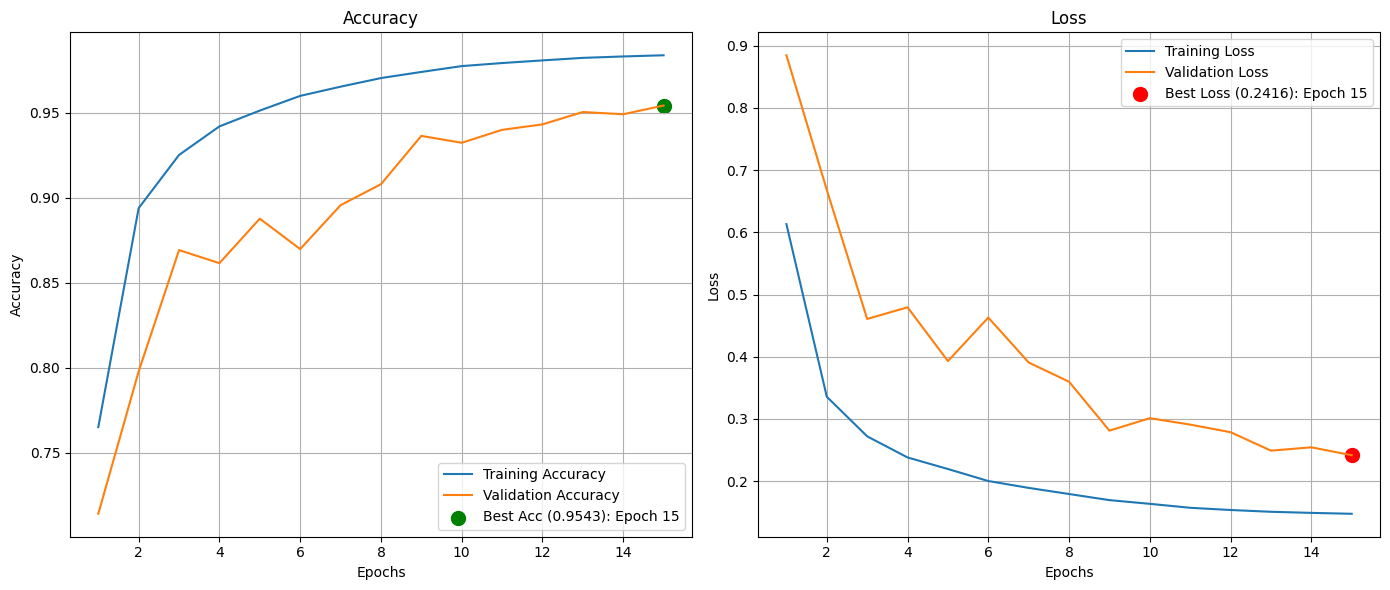

In [49]:
plot_learning_curves(history_dp)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.83      0.97      0.89      4249
          06       0.97      0.18      0.30       401
          08       0.89      0.91      0.90      2748
          12       0.66      0.79      0.72      4633
          13       0.59      0.62      0.61      3429
          14       0.46      0.02      0.05      1139
          15       0.83      0.92      0.87      6421
          16       0.97      0.54      0.69      2061
          18       0.82      0.26      0.40      1058
          21       0.70      0.87      0.78      2899
          22       0.73      0.07      0.12       895
          23       0.61      0.91      0.73      2793
          27       1.00      0.68      0.81      1670
          30       1.00      0.73      0.85       803

    accuracy                           0.76     35199
   macro avg       0.79      0.61      0.62     35199
weighted avg       0.77      0.76      0.73     35

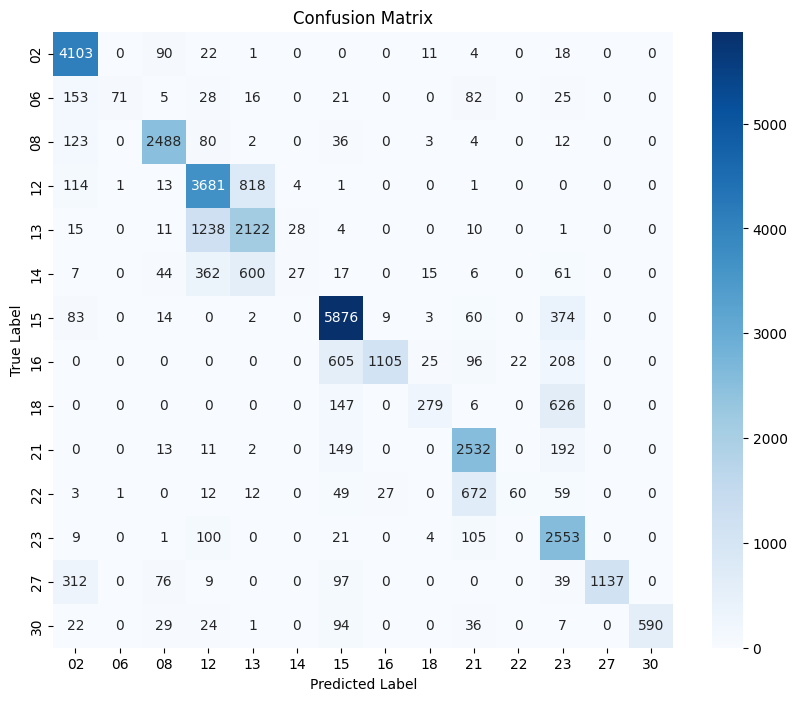

In [50]:
evaluate_model(trained_model_dp, test_loader, base_dataset.classes)

In [51]:
save_model(trained_model_dp, model_path_dp, model_name_dp)

Saved model weights for DualPathQuantumNet: DualPathQuantumNet.pth


## QuantumBoost (V1)

### Define Model

In [39]:
n_qubits_qboost = 10
n_layers_qboost = 4

In [40]:
model_name_qboost = "QuantumBoostNet"
model_path_qboost = f"{model_name_qboost}.pth"

In [41]:
dev_qboost = qml.device("default.qubit", wires=n_qubits_qboost)

@qml.qnode(dev_qboost, interface="torch")
def quantum_circuit_qboost(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_qboost))

    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_qboost))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_qboost)]

weight_shapes_qboost = {"weights": (n_layers_qboost, n_qubits_qboost, 3)}

qlayer_qboost = qnn.TorchLayer(quantum_circuit_qboost, weight_shapes_qboost)

In [42]:
class QuantumBoostNet(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(QuantumBoostNet, self).__init__()

        # Backbone (Initial Convolution)
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Quantum Path
        self.fc_to_q = nn.Linear(512, n_qubits_qboost)
        self.qlayer = qlayer_qboost
        self.fc_q_out = nn.Linear(n_qubits_qboost, num_classes)

        # Classical Boost Path
        self.classical_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        # Learnable Mixing Gate
        self.gate = nn.Parameter(torch.tensor(3.0))

        # Freeze Classical Head Initially
        self._freeze_classical_head()
        self._boost_enabled = False

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None

        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    # Freeze/Unfreeze Helpers

    def _freeze_classical_head(self):
        for param in self.classical_head.parameters():
            param.requires_grad = False

    def _unfreeze_classical_head(self):
        for param in self.classical_head.parameters():
            param.requires_grad = True

    def enable_boost(self):
        if self._boost_enabled:
            return

        self._boost_enabled = True
        self._unfreeze_classical_head()

        # Freeze Quantum Path
        self.fc_to_q.requires_grad_(False)
        for param in self.qlayer.parameters():
            param.requires_grad = False
        self.fc_q_out.requires_grad_(False)

        print("   [QuantumBoostNet] Boost enabled: classical head unfrozen, quantum path frozen.")

    def set_alpha(self, target_alpha):
        target_alpha = max(0.01, min(0.99, target_alpha))
        self.gate.data = torch.tensor(math.log(target_alpha / (1 - target_alpha)), device=self.gate.device)

    @property
    def alpha(self):
        return torch.sigmoid(self.gate).item()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        feat = torch.flatten(x, 1) # (B, 512)

        # Quantum Path
        q = self.fc_to_q(feat)      # (B, 10)
        q = torch.tanh(q) * math.pi # (B, 10) scaled to [-pi, pi]
        q = self.qlayer(q)          # (B, 10)
        q = self.fc_q_out(q)        # (B, num_classes)

        # Classical Boost Path
        c = self.classical_head(feat) # (B, num_classes)

        # Gated Fusion
        alpha = torch.sigmoid(self.gate)     # scalar in (0, 1)
        logits = alpha * q + (1 - alpha) * c # (B, num_classes)

        return logits

In [43]:
def train_model_qboost(model_name, model, criterion, optimizer, train_loader, val_loader, num_epochs_quantum, num_epochs_boost, patience=2):
    total_epochs = num_epochs_quantum + num_epochs_boost
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'alpha': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    scheduler = CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-6)

    # Plateau Detection
    plateau_counter = 0
    prev_val_acc = 0.0

    phase_label = "Quantum"
    boost_start_epoch = num_epochs_quantum
    alpha_at_boost_start = None

    print(f"Training {model_name}:")
    print(f"   Phase 1 (Quantum): {num_epochs_quantum} epochs; Phase 2 (Boost): {num_epochs_boost} epochs")
    print(f"   Plateau patience: {patience} epochs; Boost alpha target: 0.2")
    print(f"   Initial alpha: {model.alpha:.4f}")
    print(f"   LR schedule: CosineAnnealing over {total_epochs} total epochs")

    for epoch in range(total_epochs):
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{total_epochs}  [{phase_label}]  (lr={lr_now:.6f}, alpha={model.alpha:.4f}):")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc  = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"   {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        history['alpha'].append(model.alpha)
        scheduler.step()

        # Phase Transition Logic
        current_val_acc = history['val_acc'][-1]

        if phase_label == "Quantum":
            improvement = current_val_acc - prev_val_acc
            if improvement < 0.002:
                plateau_counter += 1
            else:
                plateau_counter = 0

            prev_val_acc = current_val_acc

            trigger_boost = False
            if plateau_counter >= patience:
                print(f"\n   >> Plateau detected ({plateau_counter} epochs with <0.2% improvement)")
                trigger_boost = True
            elif epoch + 1 >= num_epochs_quantum:
                print(f"\n   >> Quantum phase complete ({num_epochs_quantum} epochs)")
                trigger_boost = True

            if trigger_boost:
                phase_label = "Boost"
                boost_start_epoch = epoch + 1
                alpha_at_boost_start = model.alpha
                model.enable_boost()

                # New Optimizer For The Newly Unfrozen Parameters
                optimizer = optim.Adam(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    lr=1e-3
                )
                scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_boost, eta_min=1e-6)
                print(f"   >> New optimizer for boost phase (lr=1e-3)")
                print()

        elif phase_label == "Boost":
            # Anneal alpha linearly toward 0.2
            boost_epoch = epoch + 1 - boost_start_epoch
            boost_total = total_epochs - boost_start_epoch
            if boost_total > 0:
                progress = boost_epoch / boost_total
                target_alpha = alpha_at_boost_start + progress * (0.2 - alpha_at_boost_start)
                model.set_alpha(target_alpha)

        print()

    print(f"Best Val Acc: {best_val_acc:.4f}")
    print(f"Final alpha:  {model.alpha:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history

### Train & Save Model

In [44]:
model_qboost = QuantumBoostNet(num_classes=num_classes).to(DEVICE)

num_epochs_quantum_qboost = 10
num_epochs_boost_qboost   = 5

criterion_qboost = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qboost = optim.Adam(filter(lambda p: p.requires_grad, model_qboost.parameters()), lr=1e-3)

In [45]:
total_p_qboost     = sum(p.numel() for p in model_qboost.parameters())
trainable_p_qboost = sum(p.numel() for p in model_qboost.parameters() if p.requires_grad)
frozen_p_qboost    = total_p_qboost - trainable_p_qboost

print(f"Model: {model_name_qboost}")
print(f"   Total params:     {total_p_qboost:,}")
print(f"   Trainable params: {trainable_p_qboost:,} (backbone + quantum path)")
print(f"   Frozen params:    {frozen_p_qboost:,} (classical head - unfrozen during boost)")
print(f"   Quantum: {n_qubits_qboost} qubits, {n_layers_qboost} layers")
print(f"   Phase 1: {num_epochs_quantum_qboost} epochs (quantum)")
print(f"   Phase 2: {num_epochs_boost_qboost} epochs (classical boost)")
print(f"   Initial alpha: {model_qboost.alpha:.4f}")

Model: QuantumBoostNet
   Total params:     11,311,083
   Trainable params: 11,175,645 (backbone + quantum path)
   Frozen params:    135,438 (classical head - unfrozen during boost)
   Quantum: 10 qubits, 4 layers
   Phase 1: 10 epochs (quantum)
   Phase 2: 5 epochs (classical boost)
   Initial alpha: 0.9526


In [46]:
trained_model_qboost, history_qboost = train_model_qboost(model_name=model_name_qboost,
                                                          model=model_qboost,
                                                          criterion=criterion_qboost,
                                                          optimizer=optimizer_qboost,
                                                          train_loader=train_loader,
                                                          val_loader=val_loader,
                                                          num_epochs_quantum=num_epochs_quantum_qboost,
                                                          num_epochs_boost=num_epochs_boost_qboost,
                                                          patience=2)

Training QuantumBoostNet:
   Phase 1 (Quantum): 10 epochs; Phase 2 (Boost): 5 epochs
   Plateau patience: 2 epochs; Boost alpha target: 0.2
   Initial alpha: 0.9526
   LR schedule: CosineAnnealing over 15 total epochs
Epoch 1/15  [Quantum]  (lr=0.001000, alpha=0.9526):
   train Loss: 0.7555  Acc: 0.8375
   val   Loss: 0.0927  Acc: 0.9855

Epoch 2/15  [Quantum]  (lr=0.000989, alpha=0.4224):
   train Loss: 0.0856  Acc: 0.9850
   val   Loss: 0.0612  Acc: 0.9852

Epoch 3/15  [Quantum]  (lr=0.000957, alpha=0.3620):
   train Loss: 0.0487  Acc: 0.9876
   val   Loss: 0.0321  Acc: 0.9893

Epoch 4/15  [Quantum]  (lr=0.000905, alpha=0.3544):
   train Loss: 0.0372  Acc: 0.9882
   val   Loss: 0.0332  Acc: 0.9876

Epoch 5/15  [Quantum]  (lr=0.000835, alpha=0.3517):
   train Loss: 0.0292  Acc: 0.9890
   val   Loss: 0.0231  Acc: 0.9902

Epoch 6/15  [Quantum]  (lr=0.000750, alpha=0.3568):
   train Loss: 0.0254  Acc: 0.9894
   val   Loss: 0.0217  Acc: 0.9898

Epoch 7/15  [Quantum]  (lr=0.000655, alpha=0

In [47]:
def plot_learning_curves_qboost(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    alpha_hist = history['alpha']
    epochs = range(1, len(acc) + 1)

    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Accuracy
    axes[0].plot(epochs, acc, label='Training Accuracy')
    axes[0].plot(epochs, val_acc, label='Validation Accuracy')
    label_acc = f'Best Acc ({val_acc[best_acc_epoch]:.4f}): Epoch {best_acc_epoch + 1}'
    axes[0].scatter(best_acc_epoch + 1, val_acc[best_acc_epoch], s=100, c='green', label=label_acc)
    axes[0].legend(loc='lower right')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].grid(True)

    # Loss
    axes[1].plot(epochs, loss, label='Training Loss')
    axes[1].plot(epochs, val_loss, label='Validation Loss')
    label_loss = f'Best Loss ({val_loss[best_loss_epoch]:.4f}): Epoch {best_loss_epoch + 1}'
    axes[1].scatter(best_loss_epoch + 1, val_loss[best_loss_epoch], s=100, c='red', label=label_loss)
    axes[1].legend(loc='upper right')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)

    # Alpha
    axes[2].plot(epochs, alpha_hist, color='purple', linewidth=2, label='Alpha (quantum weight)')
    axes[2].fill_between(epochs, alpha_hist, alpha=0.15, color='purple')
    axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Equal mix')
    axes[2].legend(loc='upper right')
    axes[2].set_title('Quantum ↔ Classical Balance')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('Alpha (1=quantum, 0=classical)')
    axes[2].set_ylim(-0.05, 1.05)
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

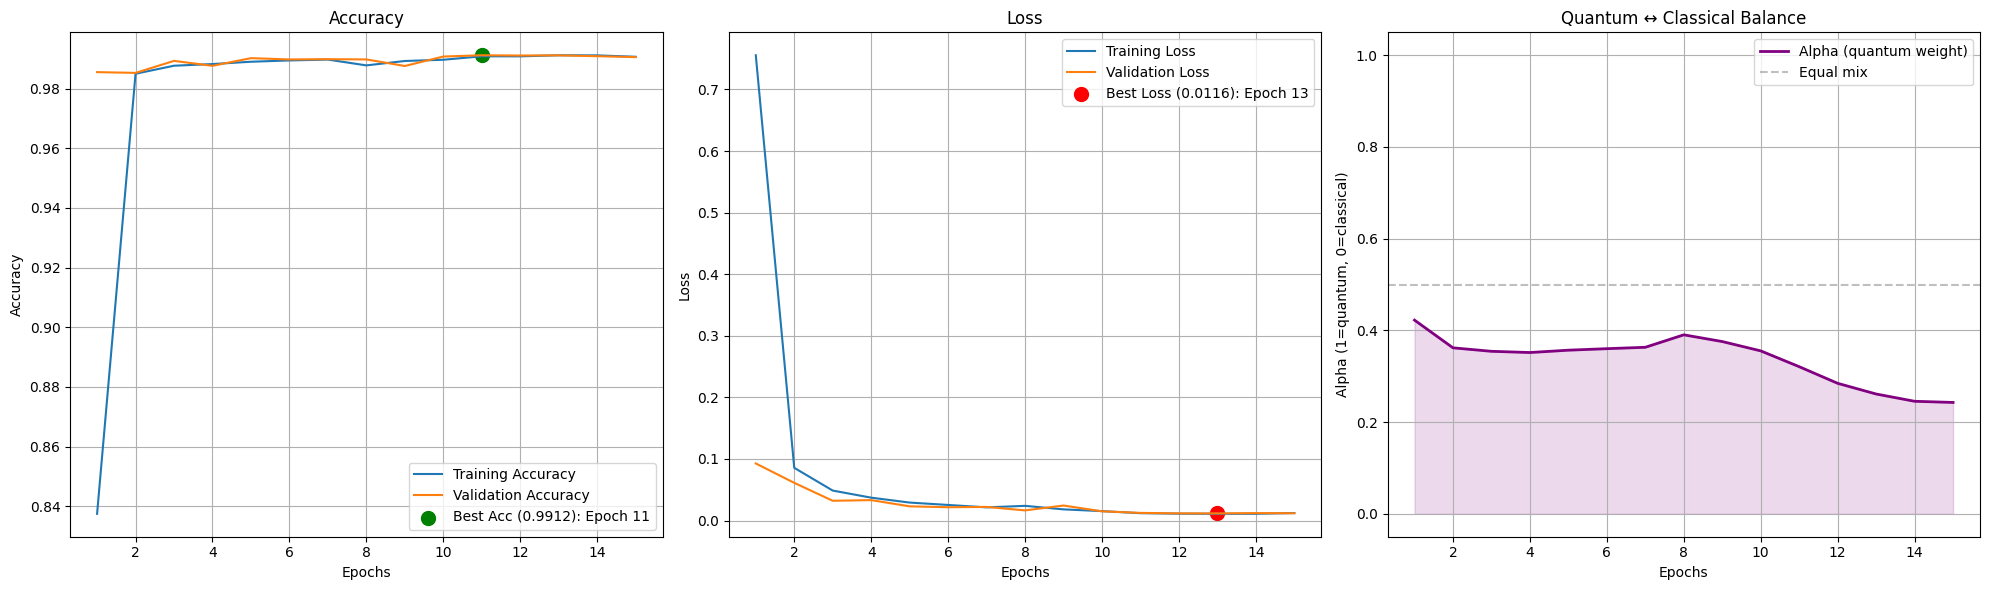

In [48]:
plot_learning_curves_qboost(history_qboost)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.92      0.93      0.93      4249
          06       0.83      0.47      0.60       401
          08       0.82      0.89      0.85      2748
          12       0.64      0.58      0.61      4633
          13       0.47      0.58      0.52      3429
          14       0.24      0.11      0.15      1139
          15       0.89      0.90      0.89      6421
          16       0.74      0.74      0.74      2061
          18       0.67      0.79      0.73      1058
          21       0.79      0.70      0.74      2899
          22       0.37      0.53      0.44       895
          23       0.90      0.87      0.89      2793
          27       0.91      0.92      0.91      1670
          30       0.99      0.92      0.95       803

    accuracy                           0.76     35199
   macro avg       0.73      0.71      0.71     35199
weighted avg       0.76      0.76      0.76     35

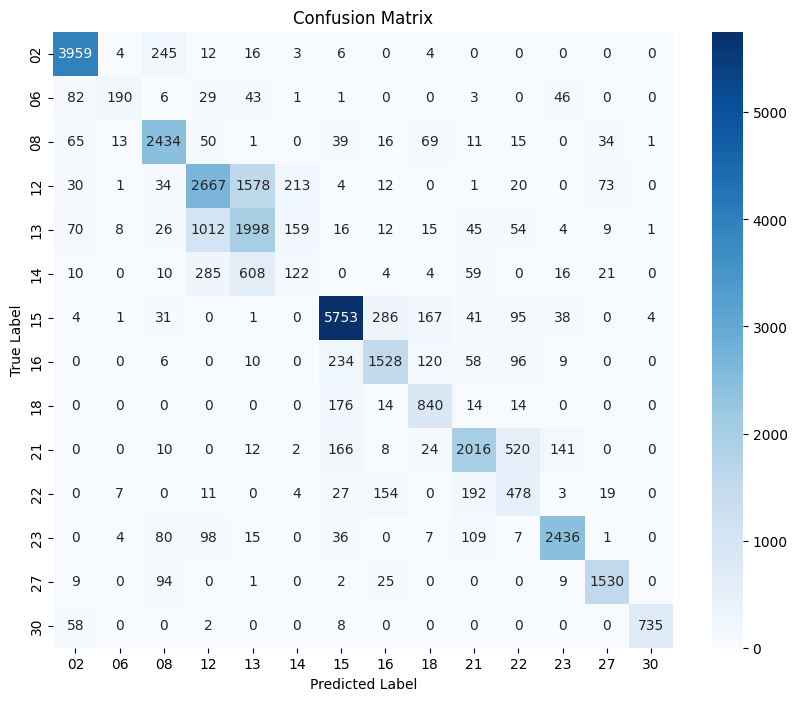

In [49]:
evaluate_model(trained_model_qboost, test_loader, base_dataset.classes)

In [50]:
save_model(trained_model_qboost, model_path_qboost, model_name_qboost)

Saved model weights for QuantumBoostNet: QuantumBoostNet.pth


## QuantumBoost (V2)

### Define Model

In [51]:
n_qubits_qboostv2 = 10
n_layers_qboostv2 = 4

In [52]:
model_name_qboostv2 = "QuantumBoostNetV2"
model_path_qboostv2 = f"{model_name_qboostv2}.pth"

In [53]:
dev_qboostv2 = qml.device("default.qubit", wires=n_qubits_qboostv2)

@qml.qnode(dev_qboostv2, interface="torch")
def quantum_circuit_qboostv2(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_qboostv2))

    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_qboostv2))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_qboostv2)]

weight_shapes_qboostv2 = {"weights": (n_layers_qboostv2, n_qubits_qboostv2, 3)}

qlayer_qboostv2 = qnn.TorchLayer(quantum_circuit_qboostv2, weight_shapes_qboostv2)

In [54]:
class QuantumBoostNetV2(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(QuantumBoostNetV2, self).__init__()

        # Backbone (Initial Convolution)
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Quantum Path
        self.fc_to_q = nn.Linear(512, n_qubits_qboostv2)
        self.qlayer = qlayer_qboostv2
        self.fc_q_out = nn.Linear(n_qubits_qboostv2, num_classes)

        # Classical Boost Path
        self.classical_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        # Phase State
        self._phase = "quantum"
        self._alpha = 1.0

        # Freeze Classical Head
        self._set_classical_head_grad(False)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None

        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    # Freeze/Unfreeze Helpers

    def _set_classical_head_grad(self, requires_grad):
        for param in self.classical_head.parameters():
            param.requires_grad = requires_grad

    def _set_quantum_path_grad(self, requires_grad):
        self.fc_to_q.requires_grad_(requires_grad)
        for param in self.qlayer.parameters():
            param.requires_grad = requires_grad
        self.fc_q_out.requires_grad_(requires_grad)

    def enable_boost(self):
        if self._phase == "boost":
            return

        self._phase = "boost"
        self._alpha = 0.8

        # Freeze Quantum, Unfreeze Classical
        self._set_quantum_path_grad(False)
        self._set_classical_head_grad(True)

        print(f"   [QuantumBoostNetV2] Phase 2 (Boost) enabled:")
        print(f"      Quantum path: FROZEN (fixed residual)")
        print(f"      Classical head: UNFROZEN (training)")
        print(f"      Initial alpha: {self._alpha}")

    @property
    def alpha(self):
        return self._alpha

    @alpha.setter
    def alpha(self, value):
        self._alpha = max(0.0, min(1.0, value))

    @property
    def phase(self):
        return self._phase

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        feat = torch.flatten(x, 1) # (B, 512)

        if self._phase == "quantum":
            q = self.fc_to_q(feat)      # (B, 10)
            q = torch.tanh(q) * math.pi # (B, 10)
            q = self.qlayer(q)          # (B, 10)
            logits = self.fc_q_out(q)   # (B, num_classes)

        else:
            with torch.no_grad():
                q = self.fc_to_q(feat)
                q = torch.tanh(q) * math.pi
                q = self.qlayer(q)
                q_logits = self.fc_q_out(q)      # (B, num_classes) — no gradients

            c_logits = self.classical_head(feat) # (B, num_classes) — has gradients

            logits = self._alpha * q_logits + (1 - self._alpha) * c_logits

        return logits

In [55]:
def train_model_qboostv2(model_name, model, criterion, optimizer, train_loader, val_loader, num_epochs_quantum, num_epochs_boost, patience=2, alpha_start=0.8, alpha_end=0.2):
    total_epochs = num_epochs_quantum + num_epochs_boost
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'alpha': [], 'phase': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    scheduler = CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-6)

    # Plateau Detection
    plateau_counter = 0
    prev_val_acc = 0.0

    boost_start_epoch = num_epochs_quantum

    print(f"Training {model_name}:")
    print(f"   Phase 1 (Quantum): {num_epochs_quantum} epochs")
    print(f"   Phase 2 (Boost): {num_epochs_boost} epochs")
    print(f"   Plateau patience: {patience} epochs (<0.2% improvement)")
    print(f"   Boost alpha: {alpha_start} → {alpha_end} (hard linear schedule)")

    for epoch in range(total_epochs):
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{total_epochs}  [{model.phase.capitalize()}]  "
              f"(lr={lr_now:.6f}, alpha={model.alpha:.4f}):")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc  = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"   {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        history['alpha'].append(model.alpha)
        history['phase'].append(model.phase)
        scheduler.step()

        # Phase Transition Logic
        current_val_acc = history['val_acc'][-1]

        if model.phase == "quantum":
            improvement = current_val_acc - prev_val_acc
            if improvement < 0.002:
                plateau_counter += 1
            else:
                plateau_counter = 0

            prev_val_acc = current_val_acc

            trigger_boost = False
            if plateau_counter >= patience:
                print(f"\n   >> Plateau detected ({plateau_counter} epochs with <0.2% improvement)")
                trigger_boost = True
            elif epoch + 1 >= num_epochs_quantum:
                print(f"\n   >> Quantum phase complete ({num_epochs_quantum} epochs)")
                trigger_boost = True

            if trigger_boost:
                boost_start_epoch = epoch + 1
                model.enable_boost()

                # New Optimizer For The Newly Unfrozen Parameters
                optimizer = optim.Adam(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    lr=1e-3
                )
                scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_boost, eta_min=1e-6)
                print(f"      New optimizer for boost phase (lr=1e-3)")
                print()

        elif model.phase == "boost":
            # Hard linear alpha anneal
            boost_epoch = epoch + 1 - boost_start_epoch
            boost_total = total_epochs - boost_start_epoch
            if boost_total > 0:
                progress = boost_epoch / boost_total
                model.alpha = alpha_start + progress * (alpha_end - alpha_start)

        print()

    print(f"Best Val Acc: {best_val_acc:.4f}")
    print(f"Final alpha:  {model.alpha:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history

### Train & Save Model

In [56]:
model_qboostv2 = QuantumBoostNetV2(num_classes=num_classes).to(DEVICE)

num_epochs_quantum_qboostv2 = 10
num_epochs_boost_qboostv2   = 5

criterion_qboostv2 = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qboostv2 = optim.Adam(filter(lambda p: p.requires_grad, model_qboostv2.parameters()), lr=1e-3)

In [57]:
total_p_qboostv2     = sum(p.numel() for p in model_qboostv2.parameters())
trainable_p_qboostv2 = sum(p.numel() for p in model_qboostv2.parameters() if p.requires_grad)
frozen_p_qboostv2    = total_p_qboostv2 - trainable_p_qboostv2

print(f"Model: {model_name_qboostv2}")
print(f"   Total params:     {total_p_qboostv2:,}")
print(f"   Trainable params: {trainable_p_qboostv2:,} (backbone + quantum path)")
print(f"   Frozen params:    {frozen_p_qboostv2:,} (classical head - excluded until boost)")
print(f"   Quantum: {n_qubits_qboostv2} qubits, {n_layers_qboostv2} layers")
print(f"   Phase 1: {num_epochs_quantum_qboostv2} epochs (quantum)")
print(f"   Phase 2: {num_epochs_boost_qboostv2} epochs (classical boost)")
print(f"   Current phase: {model_qboostv2.phase}")

Model: QuantumBoostNetV2
   Total params:     11,311,082
   Trainable params: 11,175,644 (backbone + quantum path)
   Frozen params:    135,438 (classical head - excluded until boost)
   Quantum: 10 qubits, 4 layers
   Phase 1: 10 epochs (quantum)
   Phase 2: 5 epochs (classical boost)
   Current phase: quantum


In [58]:
trained_model_qboostv2, history_qboostv2 = train_model_qboostv2(model_name=model_name_qboostv2,
                                                                model=model_qboostv2,
                                                                criterion=criterion_qboostv2,
                                                                optimizer=optimizer_qboostv2,
                                                                train_loader=train_loader,
                                                                val_loader=val_loader,
                                                                num_epochs_quantum=num_epochs_quantum_qboostv2,
                                                                num_epochs_boost=num_epochs_boost_qboostv2,
                                                                patience=2,
                                                                alpha_start=0.8,
                                                                alpha_end=0.2)

Training QuantumBoostNetV2:
   Phase 1 (Quantum): 10 epochs
   Phase 2 (Boost): 5 epochs
   Plateau patience: 2 epochs (<0.2% improvement)
   Boost alpha: 0.8 → 0.2 (hard linear schedule)
Epoch 1/15  [Quantum]  (lr=0.001000, alpha=1.0000):
   train Loss: 2.5347  Acc: 0.1120
   val   Loss: 2.0325  Acc: 0.2444

Epoch 2/15  [Quantum]  (lr=0.000989, alpha=1.0000):
   train Loss: 1.3288  Acc: 0.5249
   val   Loss: 0.6327  Acc: 0.7904

Epoch 3/15  [Quantum]  (lr=0.000957, alpha=1.0000):
   train Loss: 0.4288  Acc: 0.8176
   val   Loss: 0.3091  Acc: 0.8404

Epoch 4/15  [Quantum]  (lr=0.000905, alpha=1.0000):
   train Loss: 0.3106  Acc: 0.8333
   val   Loss: 0.2649  Acc: 0.8431

Epoch 5/15  [Quantum]  (lr=0.000835, alpha=1.0000):
   train Loss: 0.2561  Acc: 0.8574
   val   Loss: 0.2333  Acc: 0.8884

Epoch 6/15  [Quantum]  (lr=0.000750, alpha=1.0000):
   train Loss: 0.1677  Acc: 0.9291
   val   Loss: 0.0913  Acc: 0.9802

Epoch 7/15  [Quantum]  (lr=0.000655, alpha=1.0000):
   train Loss: 0.0671 

In [59]:
def plot_learning_curves_qboostv2(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    alpha_hist = history['alpha']
    phase_hist = history['phase']
    epochs = range(1, len(acc) + 1)

    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)

    # Find phase transition point
    boost_start = None
    for i, p in enumerate(phase_hist):
        if p == "boost":
            boost_start = i + 1  # 1-indexed
            break

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Accuracy
    axes[0].plot(epochs, acc, label='Training Accuracy')
    axes[0].plot(epochs, val_acc, label='Validation Accuracy')
    label_acc = f'Best Acc ({val_acc[best_acc_epoch]:.4f}): Epoch {best_acc_epoch + 1}'
    axes[0].scatter(best_acc_epoch + 1, val_acc[best_acc_epoch], s=100, c='green', label=label_acc)
    if boost_start:
        axes[0].axvline(x=boost_start, color='red', linestyle='--', alpha=0.7, label=f'Boost starts (ep {boost_start})')
    axes[0].legend(loc='lower right')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].grid(True)

    # Loss
    axes[1].plot(epochs, loss, label='Training Loss')
    axes[1].plot(epochs, val_loss, label='Validation Loss')
    label_loss = f'Best Loss ({val_loss[best_loss_epoch]:.4f}): Epoch {best_loss_epoch + 1}'
    axes[1].scatter(best_loss_epoch + 1, val_loss[best_loss_epoch], s=100, c='red', label=label_loss)
    if boost_start:
        axes[1].axvline(x=boost_start, color='red', linestyle='--', alpha=0.7, label=f'Boost starts (ep {boost_start})')
    axes[1].legend(loc='upper right')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)

    # Alpha + Phase
    axes[2].plot(epochs, alpha_hist, color='purple', linewidth=2, label='Alpha (quantum weight)')
    axes[2].fill_between(epochs, alpha_hist, alpha=0.15, color='purple')
    axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Equal mix')
    if boost_start:
        axes[2].axvline(x=boost_start, color='red', linestyle='--', alpha=0.7, label=f'Boost starts (ep {boost_start})')
    axes[2].legend(loc='upper right')
    axes[2].set_title('Quantum ↔ Classical Balance')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('Alpha (1=quantum, 0=classical)')
    axes[2].set_ylim(-0.05, 1.05)
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

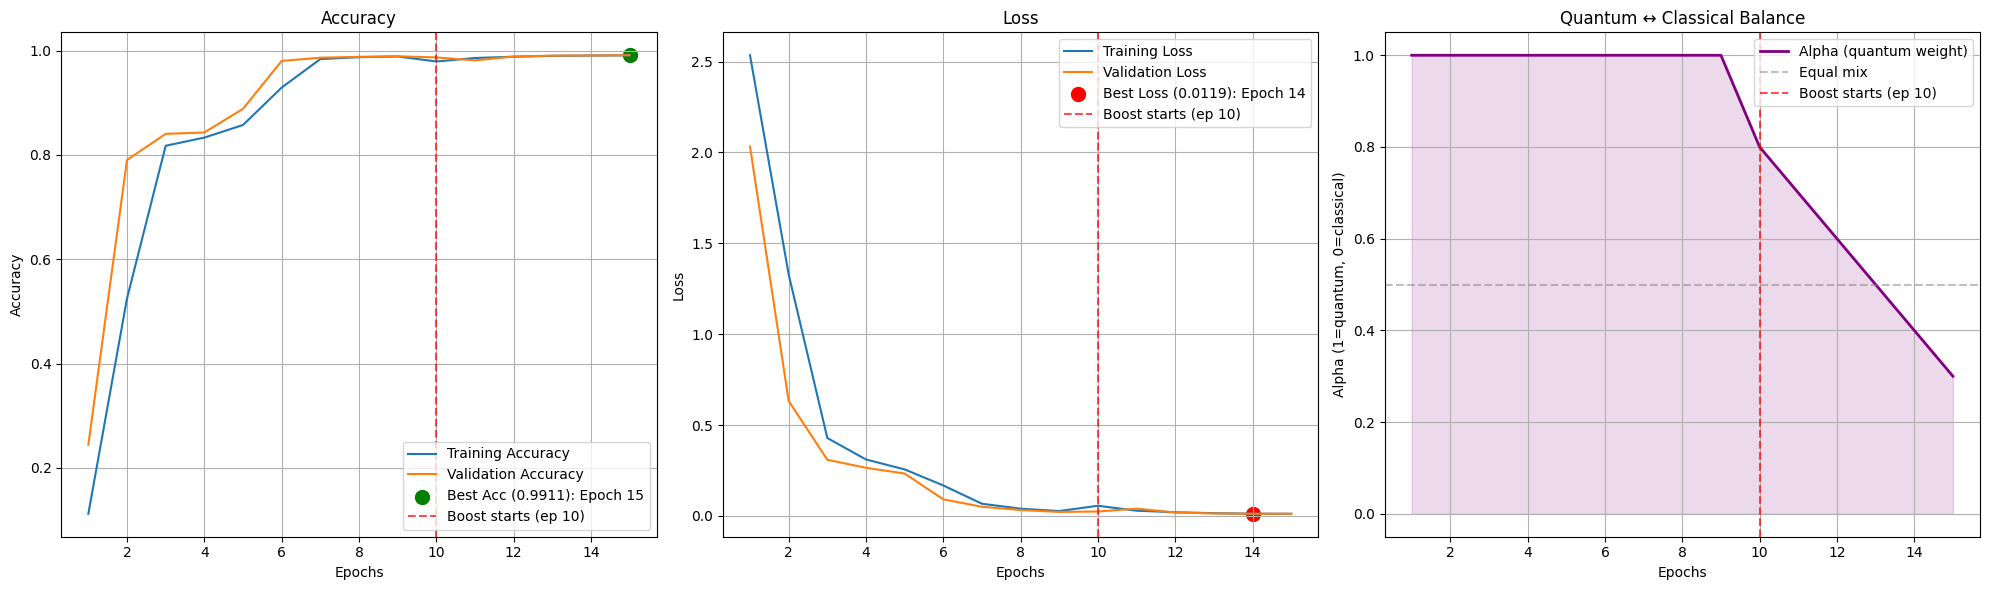

In [60]:
plot_learning_curves_qboostv2(history_qboostv2)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.92      0.92      0.92      4249
          06       0.75      0.11      0.19       401
          08       0.84      0.89      0.86      2748
          12       0.58      0.59      0.58      4633
          13       0.44      0.55      0.49      3429
          14       0.16      0.07      0.10      1139
          15       0.89      0.89      0.89      6421
          16       0.75      0.79      0.77      2061
          18       0.66      0.56      0.60      1058
          21       0.80      0.81      0.81      2899
          22       0.64      0.60      0.62       895
          23       0.91      0.87      0.89      2793
          27       0.84      0.94      0.89      1670
          30       0.96      0.86      0.91       803

    accuracy                           0.75     35199
   macro avg       0.72      0.67      0.68     35199
weighted avg       0.75      0.75      0.75     35

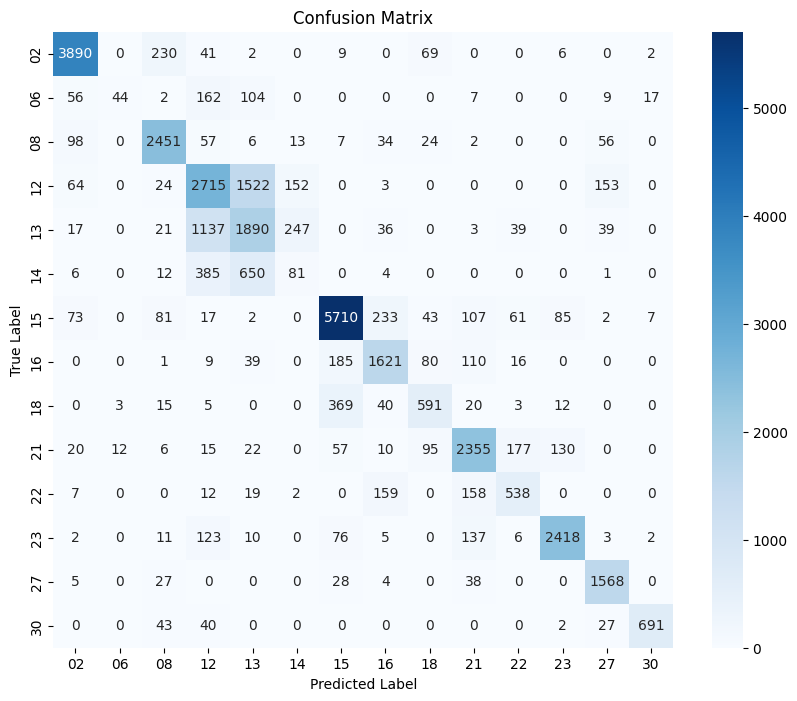

In [61]:
evaluate_model(trained_model_qboostv2, test_loader, base_dataset.classes)

In [62]:
save_model(trained_model_qboostv2, model_path_qboostv2, model_name_qboostv2)

Saved model weights for QuantumBoostNetV2: QuantumBoostNetV2.pth


## QuantumBoost (V3)

### Define Model

In [63]:
n_qubits_qboostv3 = 10
n_layers_qboostv3 = 4

In [64]:
model_name_qboostv3 = "QuantumBoostNetV3"
model_path_qboostv3 = f"{model_name_qboostv3}.pth"

In [65]:
dev_qboostv3 = qml.device("default.qubit", wires=n_qubits_qboostv3)

@qml.qnode(dev_qboostv3, interface="torch")
def quantum_circuit_qboostv3(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_qboostv3))

    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_qboostv3))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_qboostv3)]

weight_shapes_qboostv3 = {"weights": (n_layers_qboostv3, n_qubits_qboostv3, 3)}

qlayer_qboostv3 = qnn.TorchLayer(quantum_circuit_qboostv3, weight_shapes_qboostv3)

In [66]:
class QuantumBoostNetV3(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(QuantumBoostNetV3, self).__init__()

        # Backbone (Initial Convolution)
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Quantum Path
        self.fc_to_q = nn.Linear(512, n_qubits_qboostv3)
        self.qlayer = qlayer_qboostv3
        self.fc_q_out = nn.Linear(n_qubits_qboostv3, num_classes)

        # Classical Path
        self.classical_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        # Learnable Mixing Gate
        self.gate = nn.Parameter(torch.tensor(-3.0))

        # Freeze Quantum Head Initially
        self._freeze_quantum_path()
        self._boost_enabled = False

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None

        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    # Freeze/Unfreeze Helpers

    def _freeze_quantum_path(self):
        self.fc_to_q.requires_grad_(False)
        for param in self.qlayer.parameters():
            param.requires_grad = False
        self.fc_q_out.requires_grad_(False)

    def _unfreeze_quantum_path(self):
        self.fc_to_q.requires_grad_(True)
        for param in self.qlayer.parameters():
            param.requires_grad = True
        self.fc_q_out.requires_grad_(True)

    def _freeze_classical_head(self):
        for param in self.classical_head.parameters():
            param.requires_grad = False

    def _unfreeze_classical_head(self):
        for param in self.classical_head.parameters():
            param.requires_grad = True

    def enable_boost(self):
        if self._boost_enabled:
            return

        self._boost_enabled = True

        # Freeze Classical, Unfreeze Quantum
        self._freeze_classical_head()
        self._unfreeze_quantum_path()

        print("   [QuantumBoostNetV3] Boost enabled: quantum path unfrozen, classical head frozen.")

    def set_alpha(self, target_alpha):
        target_alpha = max(0.01, min(0.99, target_alpha))
        self.gate.data = torch.tensor(
            math.log(target_alpha / (1 - target_alpha)),
            device=self.gate.device
        )

    @property
    def alpha(self):
        return torch.sigmoid(self.gate).item()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        feat = torch.flatten(x, 1) # (B, 512)

        # Quantum Path
        q = self.fc_to_q(feat)      # (B, 10)
        q = torch.tanh(q) * math.pi # (B, 10) scaled to [-pi, pi]
        q = self.qlayer(q)          # (B, 10)
        q = self.fc_q_out(q)        # (B, num_classes)

        # Classical Path
        c = self.classical_head(feat) # (B, num_classes)

        # Gated Fusion
        alpha = torch.sigmoid(self.gate)     # scalar in (0, 1)
        logits = alpha * q + (1 - alpha) * c # (B, num_classes)

        return logits

### Train & Save Model

In [67]:
def train_model_qboostv3(model_name, model, criterion, optimizer, train_loader, val_loader, num_epochs_classical, num_epochs_boost, patience=2):
    total_epochs = num_epochs_classical + num_epochs_boost
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'alpha': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    scheduler = CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-6)

    # Plateau Detection
    plateau_counter = 0
    prev_val_acc = 0.0

    phase_label = "Classical"
    boost_start_epoch = num_epochs_classical
    alpha_at_boost_start = None

    print(f"Training {model_name}:")
    print(f"   Phase 1 (Classical): {num_epochs_classical} epochs; Phase 2 (Quantum Boost): {num_epochs_boost} epochs")
    print(f"   Plateau patience: {patience} epochs; Boost alpha target: 0.8")
    print(f"   Initial alpha: {model.alpha:.4f}")
    print(f"   LR schedule: CosineAnnealing over {total_epochs} total epochs")

    for epoch in range(total_epochs):
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{total_epochs}  [{phase_label}]  (lr={lr_now:.6f}, alpha={model.alpha:.4f}):")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc  = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"   {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        history['alpha'].append(model.alpha)
        scheduler.step()

        # Phase Transition Logic
        current_val_acc = history['val_acc'][-1]

        if phase_label == "Classical":
            improvement = current_val_acc - prev_val_acc
            if improvement < 0.002:
                plateau_counter += 1
            else:
                plateau_counter = 0

            prev_val_acc = current_val_acc

            trigger_boost = False
            if plateau_counter >= patience:
                print(f"\n   >> Plateau detected ({plateau_counter} epochs with <0.2% improvement)")
                trigger_boost = True
            elif epoch + 1 >= num_epochs_classical:
                print(f"\n   >> Classical phase complete ({num_epochs_classical} epochs)")
                trigger_boost = True

            if trigger_boost:
                phase_label = "Quantum Boost"
                boost_start_epoch = epoch + 1
                alpha_at_boost_start = model.alpha
                model.enable_boost()

                # New optimizer for the newly unfrozen quantum parameters
                optimizer = optim.Adam(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    lr=1e-3
                )
                scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_boost, eta_min=1e-6)
                print(f"   >> New optimizer for quantum boost phase (lr=1e-3)")
                print()

        elif phase_label == "Quantum Boost":
            # Anneal alpha linearly toward 0.8 (quantum-dominant)
            boost_epoch = epoch + 1 - boost_start_epoch
            boost_total = total_epochs - boost_start_epoch
            if boost_total > 0:
                progress = boost_epoch / boost_total
                target_alpha = alpha_at_boost_start + progress * (0.8 - alpha_at_boost_start)
                model.set_alpha(target_alpha)

        print()

    print(f"Best Val Acc: {best_val_acc:.4f}")
    print(f"Final alpha:  {model.alpha:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history

In [68]:
model_qboostv3 = QuantumBoostNetV3(num_classes=num_classes).to(DEVICE)

num_epochs_classical_qboostv3 = 10
num_epochs_boost_qboostv3     = 5

criterion_qboostv3 = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qboostv3 = optim.Adam(filter(lambda p: p.requires_grad, model_qboostv3.parameters()), lr=1e-3)

In [69]:
total_p_qboostv3     = sum(p.numel() for p in model_qboostv3.parameters())
trainable_p_qboostv3 = sum(p.numel() for p in model_qboostv3.parameters() if p.requires_grad)
frozen_p_qboostv3    = total_p_qboostv3 - trainable_p_qboostv3

print(f"Model: {model_name_qboostv3}")
print(f"   Total params:     {total_p_qboostv3:,}")
print(f"   Trainable params: {trainable_p_qboostv3:,} (backbone + classical head)")
print(f"   Frozen params:    {frozen_p_qboostv3:,} (quantum path - unfrozen during boost)")
print(f"   Quantum: {n_qubits_qboostv3} qubits, {n_layers_qboostv3} layers")
print(f"   Phase 1: {num_epochs_classical_qboostv3} epochs (classical-guided)")
print(f"   Phase 2: {num_epochs_boost_qboostv3} epochs (quantum boost)")
print(f"   Initial alpha: {model_qboostv3.alpha:.4f}")

Model: QuantumBoostNetV3
   Total params:     11,311,083
   Trainable params: 11,305,679 (backbone + classical head)
   Frozen params:    5,404 (quantum path - unfrozen during boost)
   Quantum: 10 qubits, 4 layers
   Phase 1: 10 epochs (classical-guided)
   Phase 2: 5 epochs (quantum boost)
   Initial alpha: 0.0474


In [70]:
trained_model_qboostv3, history_qboostv3 = train_model_qboostv3(model_name=model_name_qboostv3,
                                                                model=model_qboostv3,
                                                                criterion=criterion_qboostv3,
                                                                optimizer=optimizer_qboostv3,
                                                                train_loader=train_loader,
                                                                val_loader=val_loader,
                                                                num_epochs_classical=num_epochs_classical_qboostv3,
                                                                num_epochs_boost=num_epochs_boost_qboostv3,
                                                                patience=2)

Training QuantumBoostNetV3:
   Phase 1 (Classical): 10 epochs; Phase 2 (Quantum Boost): 5 epochs
   Plateau patience: 2 epochs; Boost alpha target: 0.8
   Initial alpha: 0.0474
   LR schedule: CosineAnnealing over 15 total epochs
Epoch 1/15  [Classical]  (lr=0.001000, alpha=0.0474):
   train Loss: 0.2930  Acc: 0.8920
   val   Loss: 0.1178  Acc: 0.9585

Epoch 2/15  [Classical]  (lr=0.000989, alpha=0.0192):
   train Loss: 0.0586  Acc: 0.9757
   val   Loss: 0.0492  Acc: 0.9810

Epoch 3/15  [Classical]  (lr=0.000957, alpha=0.0173):
   train Loss: 0.0381  Acc: 0.9824
   val   Loss: 0.0282  Acc: 0.9861

Epoch 4/15  [Classical]  (lr=0.000905, alpha=0.0185):
   train Loss: 0.0273  Acc: 0.9857
   val   Loss: 0.0309  Acc: 0.9846

Epoch 5/15  [Classical]  (lr=0.000835, alpha=0.0203):
   train Loss: 0.0227  Acc: 0.9873
   val   Loss: 0.0201  Acc: 0.9894

Epoch 6/15  [Classical]  (lr=0.000750, alpha=0.0229):
   train Loss: 0.0194  Acc: 0.9882
   val   Loss: 0.0146  Acc: 0.9895

Epoch 7/15  [Classic

In [71]:
def plot_learning_curves_qboostv3(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    alpha_hist = history['alpha']
    epochs = range(1, len(acc) + 1)

    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Accuracy
    axes[0].plot(epochs, acc, label='Training Accuracy')
    axes[0].plot(epochs, val_acc, label='Validation Accuracy')
    label_acc = f'Best Acc ({val_acc[best_acc_epoch]:.4f}): Epoch {best_acc_epoch + 1}'
    axes[0].scatter(best_acc_epoch + 1, val_acc[best_acc_epoch], s=100, c='green', label=label_acc)
    axes[0].legend(loc='lower right')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].grid(True)

    # Loss
    axes[1].plot(epochs, loss, label='Training Loss')
    axes[1].plot(epochs, val_loss, label='Validation Loss')
    label_loss = f'Best Loss ({val_loss[best_loss_epoch]:.4f}): Epoch {best_loss_epoch + 1}'
    axes[1].scatter(best_loss_epoch + 1, val_loss[best_loss_epoch], s=100, c='red', label=label_loss)
    axes[1].legend(loc='upper right')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)

    # Alpha (Quantum vs Classical mix)
    axes[2].plot(epochs, alpha_hist, color='purple', linewidth=2, label='Alpha (quantum weight)')
    axes[2].fill_between(epochs, alpha_hist, alpha=0.15, color='purple')
    axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Equal mix')
    axes[2].legend(loc='lower right')
    axes[2].set_title('Quantum ↔ Classical Balance')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('Alpha (1=quantum, 0=classical)')
    axes[2].set_ylim(-0.05, 1.05)
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

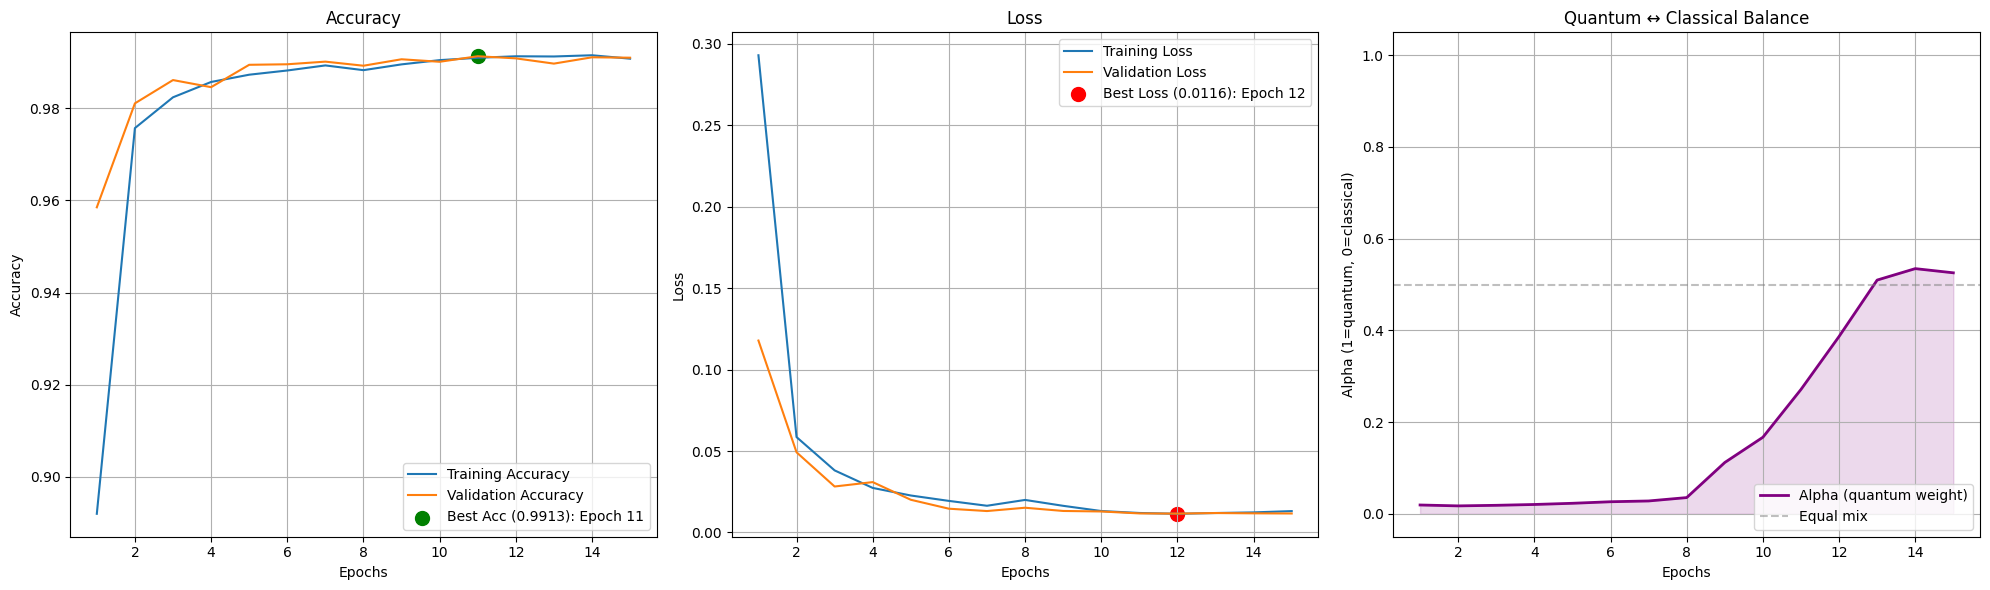

In [72]:
plot_learning_curves_qboostv3(history_qboostv3)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.93      0.93      0.93      4249
          06       0.72      0.27      0.39       401
          08       0.79      0.91      0.85      2748
          12       0.59      0.64      0.62      4633
          13       0.47      0.42      0.44      3429
          14       0.14      0.12      0.13      1139
          15       0.84      0.91      0.87      6421
          16       0.72      0.71      0.71      2061
          18       0.67      0.73      0.70      1058
          21       0.84      0.73      0.78      2899
          22       0.69      0.56      0.62       895
          23       0.89      0.89      0.89      2793
          27       0.95      0.89      0.92      1670
          30       0.98      0.90      0.94       803

    accuracy                           0.75     35199
   macro avg       0.73      0.69      0.70     35199
weighted avg       0.75      0.75      0.75     35

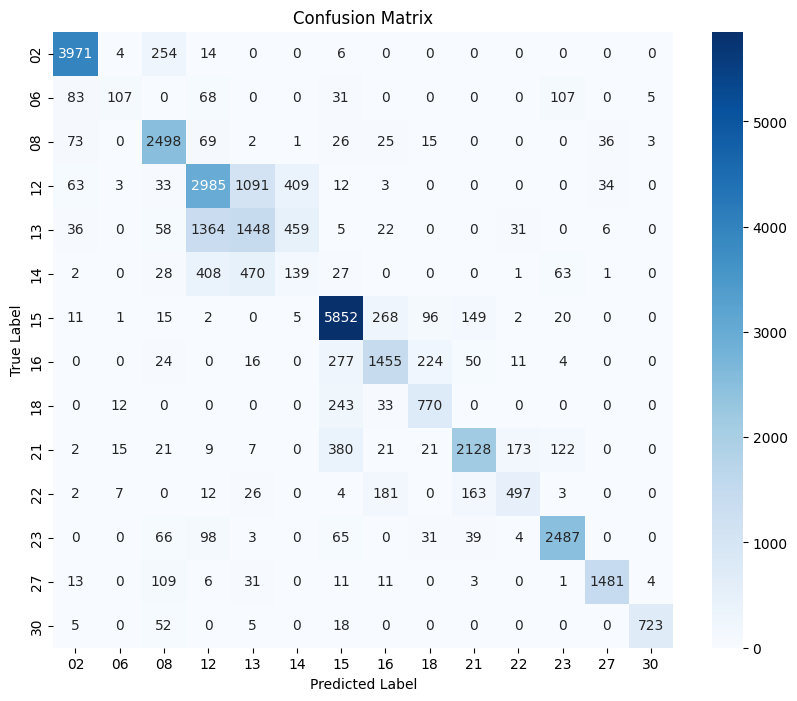

In [73]:
evaluate_model(trained_model_qboostv3, test_loader, base_dataset.classes)

In [74]:
save_model(trained_model_qboostv3, model_path_qboostv3, model_name_qboostv3)

Saved model weights for QuantumBoostNetV3: QuantumBoostNetV3.pth
